# TA-RecMind V2 — Intra-Layer Gated Fusion

Kiến trúc cập nhật theo phân tích toàn diện: intra-layer gated fusion, positive warm-tail oversampling nhẹ, uniform warm negative sampling, stratified evaluation.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 0: CÀI ĐẶT & BIẾN MÔI TRƯỜNG
# ═══════════════════════════════════════════════════════════════════════════════
import os
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True,max_split_size_mb:256"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

!pip install -q sentence-transformers huggingface_hub datasets

In [ ]:
# =============================================================================
# CELL 1: IMPORTS & CENTRAL CONFIG
# =============================================================================
import os, random, gc, json, time, threading, subprocess, psutil
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from huggingface_hub import hf_hub_download
from datasets import load_dataset
from sentence_transformers import SentenceTransformer
from tqdm.auto import tqdm

# Mount Google Drive
try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    IN_COLAB = True
    print("[INFO] Google Drive mounted.")
except ImportError:
    IN_COLAB = False
    print("[WARN] Not running in Colab. Running local mode.")

_DRIVE_ROOT = "/content/drive/MyDrive/tarecmindV2"

CFG = {
    # Repos / paths
    "REPO_ID": "chuongdo1104/amazon-2023-gold",
    "SILVER_REPO_ID": "chuongdo1104/amazon-2023-silver",
    "DATA_VERSION": "amazon_2023_electronics_full_20260525",
    "DRIVE_ROOT": _DRIVE_ROOT,
    "DATA_DIR": f"{_DRIVE_ROOT}/data",
    "SAVE_DIR": f"{_DRIVE_ROOT}/weights",
    "CACHE_DIR": "/content/recsys_cache",

    # Model
    "EMBED_DIM": 128,
    "LLM_DIM": 384,
    "TEXT_ENCODER_NAME": "all-MiniLM-L6-v2",
    "TEXT_PROFILE_VERSION": "field_tagged_posneg_v2",
    "GCN_LAYERS": 2,
    "TEMPERATURE": 0.2,

    # Training
    "EPOCHS": 50,
    "LR_JOINT": 1e-3,
    "WEIGHT_DECAY": 1e-4,
    "GRAD_CLIP": 1.0,
    "CACHE_REFRESH": 1,
    "CHUNK_STEPS": 64,

    # Main loss: BPR + graph-text alignment
    "LOSS_TYPE": "bpr_graph_text_align_v1",
    "ALIGN_WARMUP_EPOCHS": 3,
    "LAMBDA_U_ALIGN": 0.05,
    "LAMBDA_I_ALIGN": 0.05,

    # Sampling
    "TAIL_POSITIVE_SAMPLE_RATIO": 0.20,
    "NEGATIVE_POPULARITY_SAMPLE_RATIO": 0.20,

    # Evaluation / checkpoint
    "EVAL_EVERY": 2,
    "MIN_EPOCHS": 20,
    "MIN_DELTA": 1e-4,
    "REP_VAL_EVERY": 5,
    "REP_VAL_N": 100000,
    "REP_VAL_SEED": 2026,
    "USE_REPRESENTATIVE_FOR_BEST": True,
    "PATIENCE_REP": 4,

    "FAST_SCORE_TYPE": "tail_monitor_v2",
    "FAST_SCORE_WEIGHTS": {
        "TailNDCG": 0.70,
        "TailRecall": 0.20,
        "TailCoverage": 0.10,
    },

    "CHECKPOINT_SCORE_TYPE": "weighted_hmean_warm_tail_overall_ndcg_v2",
    "CHECKPOINT_W_TAIL": 2.0,
    "CHECKPOINT_W_OVERALL": 1.0,
    "CHECKPOINT_BASELINE_OVERALL_NDCG": None,
    "CHECKPOINT_OVERALL_GUARDRAIL_RATIO": 0.95,

    # Protocol
    "IGNORE_COLD_ITEMS": True,
    "EVAL_PROTOCOL": "warm_long_tail_v1",
    "MASK_VALIDATION_IN_TEST": True,

    "EVAL_STRAT_GROUPS": {
        "HEAD": 5000,
        "MID": 5000,
        "TAIL": 20000,
    },

    # LLM encoding
    "ENCODE_CHUNK": 30000,
    "ENCODE_BATCH": 256,

    # Runtime
    "SEED": 2026,
    "KEEPALIVE_MINS": 25,
}

for d in [CFG["DATA_DIR"], CFG["SAVE_DIR"], CFG["CACHE_DIR"]]:
    os.makedirs(d, exist_ok=True)


def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


seed_everything(CFG["SEED"])
print("[INFO] V2 config is ready.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[INFO] Google Drive mounted.
[INFO] V2 config is ready.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 2: PHÁT HIỆN GPU & ĐIỀU CHỈNH BATCH SIZE
# ═══════════════════════════════════════════════════════════════════════════════
def detect_and_adjust_gpu():
    sys_ram_gb = psutil.virtual_memory().total / 1e9
    print(f"[INFO] System RAM: {sys_ram_gb:.1f} GB")

    if not torch.cuda.is_available():
        print("[WARN] Không có GPU.")
        return "cpu"

    gpu_name = torch.cuda.get_device_name(0)
    vram_gb  = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"[INFO] GPU: {gpu_name} | VRAM: {vram_gb:.1f} GB")

    # Sửa lại logic dựa vào VRAM thay vì string name để tránh nhầm lẫn A100 40GB/80GB
    if vram_gb > 70:
        # Chế độ A100 80GB
        CFG["BATCH_SIZE"]     = 32768
        CFG["ALIGN_SUBBATCH"] = 8192
        CFG["ACCUM_STEPS"]    = 1
        CFG["ENCODE_BATCH"]   = 1024
        print(f"   → Chế độ VRAM > 70GB: batch={CFG['BATCH_SIZE']}, subbatch={CFG['ALIGN_SUBBATCH']}")
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
        torch.backends.cudnn.benchmark = True
    elif vram_gb > 35:
        # Chế độ A100 40GB (Tăng 2x BATCH_SIZE so với trước)
        CFG["BATCH_SIZE"]     = 16384
        CFG["ALIGN_SUBBATCH"] = 4096
        CFG["ACCUM_STEPS"]    = 2
        CFG["ENCODE_BATCH"]   = 512
        print(f"   → Chế độ VRAM > 35GB (A100 40G): batch={CFG['BATCH_SIZE']}, accum={CFG['ACCUM_STEPS']}")
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
        torch.backends.cudnn.benchmark = True
    elif vram_gb > 16:
        # Chế độ V100/L4 24GB
        CFG["BATCH_SIZE"]     = 4096
        CFG["ALIGN_SUBBATCH"] = 1024
        CFG["ACCUM_STEPS"]    = 4
        CFG["ENCODE_BATCH"]   = 512
        print(f"   → Chế độ VRAM > 16GB: batch={CFG['BATCH_SIZE']}, accum={CFG['ACCUM_STEPS']}")
    else:
        # Chế độ T4 16GB
        CFG["BATCH_SIZE"]     = 2048
        CFG["ALIGN_SUBBATCH"] = 512
        CFG["ACCUM_STEPS"]    = 4
        CFG["ENCODE_BATCH"]   = 256
        print(f"   → Chế độ T4 (<16GB): batch={CFG['BATCH_SIZE']}, accum={CFG['ACCUM_STEPS']}")

    return "cuda"

device = detect_and_adjust_gpu()

# ── Keep-alive thread ──────────────────────────────────────────────────────────────────────────────
_keepalive_stop = threading.Event()
def _keepalive_worker():
    interval = CFG["KEEPALIVE_MINS"] * 60
    ka_file  = os.path.join(CFG["CACHE_DIR"], "keepalive.txt")
    while not _keepalive_stop.is_set():
        time.sleep(interval)
        if not _keepalive_stop.is_set():
            with open(ka_file, "w") as f:
                f.write(f"alive {time.strftime('%H:%M:%S')}\n")

threading.Thread(target=_keepalive_worker, daemon=True).start()
print(f"[INFO] Keep-alive thread started. Device: {device}")


[INFO] System RAM: 89.6 GB
[INFO] GPU: NVIDIA A100-SXM4-40GB | VRAM: 42.4 GB
   → Chế độ VRAM > 35GB (A100 40G): batch=16384, accum=2
[INFO] Keep-alive thread started. Device: cuda


In [ ]:

# ═══════════════════════════════════════════════════════════════════════════════
# CELL 3: TẢI DỮ LIỆU & THÔNG TIN GRAPH
# Cập nhật theo pipeline thực tế (gold_step1, gold_step2, gold_step5)
# Artifacts: gold_dataset_stats.json, gold_edge_index.npy,
#            gold_item_train_freq.npy, gold_item_popularity_group.npy,
#            gold_user_train_freq.npy,  gold_user_activity_group.npy,
#            gold_negative_sampling_prob.npy
# ═══════════════════════════════════════════════════════════════════════════════

POP_GROUP  = {0: "HEAD", 1: "MID", 2: "TAIL", 3: "COLD_START"}
USER_GROUP = {0: "INACTIVE", 1: "ACTIVE", 2: "SUPER_ACTIVE"}

def download_hf(filename, local_dir=None):
    target      = local_dir or CFG["CACHE_DIR"]
    local_path  = os.path.join(target, filename)
    legacy_path = os.path.join(target, os.path.basename(filename))
    if os.path.exists(local_path):
        return local_path
    if os.path.exists(legacy_path):
        return legacy_path
    print(f"[INFO] Đang tải {filename}...")
    return hf_hub_download(
        repo_id=CFG["REPO_ID"], filename=filename,
        repo_type="dataset", local_dir=target,
    )

# ── 1. Dataset stats (n_users, n_items, sparsity …) ──────────────────────────
print("\n--- TẢI METADATA ---")
with open(download_hf("gold/gold_dataset_stats.json"), "r") as f:
    dataset_stats = json.load(f)

num_users   = dataset_stats["n_users"]
num_items   = dataset_stats["n_items"]
total_nodes = num_users + num_items
print(f"[INFO] {num_users:,} users | {num_items:,} items | {total_nodes:,} nodes tổng")
print(f"[INFO] Sparsity: {dataset_stats.get('sparsity_pct','N/A')} | "
      f"Avg degree user: {dataset_stats.get('avg_degree_user','N/A')}")

# ── 2. Edge index [2, E] ──────────────────────────────────────────────────────
edge_index_raw = np.load(download_hf("gold/gold_edge_index.npy"))
train_edge_index = torch.from_numpy(edge_index_raw).long()
n_train_edges    = train_edge_index.shape[1]
del edge_index_raw

# ── 3. Item frequency & popularity group ─────────────────────────────────────
item_train_freq_np    = np.load(download_hf("gold/gold_item_train_freq.npy"))          # int64
item_pop_group_np     = np.load(download_hf("gold/gold_item_popularity_group.npy"))    # int8: 0=HEAD,1=MID,2=TAIL,3=COLD
item_train_freq_t     = torch.from_numpy(item_train_freq_np).long()
item_pop_group_t      = torch.from_numpy(item_pop_group_np.astype("int32")).long()

# ── 4. User frequency & activity group ───────────────────────────────────────
user_train_freq_np    = np.load(download_hf("gold/gold_user_train_freq.npy"))          # int64
user_activity_group_np = np.load(download_hf("gold/gold_user_activity_group.npy"))    # int8: 0=INACTIVE,1=ACTIVE,2=SUPER_ACTIVE
user_train_freq_t      = torch.from_numpy(user_train_freq_np).long()
user_activity_group_t  = torch.from_numpy(user_activity_group_np.astype("int32")).long()

# ── 5. Gold blended negative-sampling probability ───────────────────────────
neg_prob_np = np.load(download_hf("gold/gold_negative_sampling_prob.npy"))  # float32, sum ~= 1
neg_prob_t  = torch.from_numpy(neg_prob_np).float()

# -- 6. Tail edge indices (oversampling in training loop) ---------------------
# TAIL = group code 2 (theo POP_GROUP_MAP trong gold_step5)
# Ngưỡng freq <= 5 tương ứng định nghĩa TAIL; dùng pop_group trực tiếp để nhất quán
tail_item_mask    = (item_pop_group_t == 2)                    # TAIL items (group code 2)
is_tail_edge      = tail_item_mask[train_edge_index[1]]        # item node ở hàng 1 của edge_index
tail_edge_indices = torch.where(is_tail_edge)[0]

# -- 7. Sanity checks ---------------------------------------------------------
assert n_train_edges > 0,               "Edge list rỗng!"
assert len(item_train_freq_np) == num_items, \
    f"item_freq length {len(item_train_freq_np)} != num_items {num_items}"
assert len(user_train_freq_np) == num_users, \
    f"user_freq length {len(user_train_freq_np)} != num_users {num_users}"
assert len(neg_prob_np) == num_items, "neg_prob length != num_items"
assert abs(float(neg_prob_np.sum()) - 1.0) < 5e-4, "neg_prob does not sum to 1"

# -- 8. Log popularity / activity distribution --------------------------------
print(f"\n[INFO] {n_train_edges:,} edges | {int(tail_edge_indices.shape[0]):,} tail edges")
print("[INFO] Item popularity distribution:")
for code, name in POP_GROUP.items():
    cnt = int((item_pop_group_t == code).sum())
    print(f"  {name:10s}: {cnt:,} ({cnt/num_items*100:.1f}%)")
print("[INFO] User activity distribution:")
for code, name in USER_GROUP.items():
    cnt = int((user_activity_group_t == code).sum())
    print(f"  {name:12s}: {cnt:,} ({cnt/num_users*100:.1f}%)")
print(f"\n[SUCCESS] Dữ liệu graph đã sẵn sàng.")

# -- 9. Release numpy arrays, keep tensors -----------------------------------
del item_train_freq_np, item_pop_group_np
del user_train_freq_np, user_activity_group_np, neg_prob_np
gc.collect()



--- TẢI METADATA ---
[INFO] 1,847,662 users | 1,610,012 items | 3,457,674 nodes tổng
[INFO] Sparsity: 99.9995% | Avg degree user: 7.56

[INFO] 13,964,281 edges | 1,212,254 tail edges
[INFO] Item popularity distribution:
  HEAD      : 210,925 (13.1%)
  MID       : 116,283 (7.2%)
  TAIL      : 714,913 (44.4%)
  COLD_START: 567,891 (35.3%)
[INFO] User activity distribution:
  INACTIVE    : 827,127 (44.8%)
  ACTIVE      : 927,738 (50.2%)
  SUPER_ACTIVE: 92,797 (5.0%)

[SUCCESS] Dữ liệu graph đã sẵn sàng.


180

In [ ]:

# ═══════════════════════════════════════════════════════════════════════════════
# CELL 4: LLM EMBEDDINGS — DRIVE-BACKED CACHE (chunk-by-chunk, chống OOM)
# Cập nhật theo pipeline thực tế:
#   - silver_item_text_profile.parquet  → col "item_text" (partitioned by popularity_group)
#   - silver_user_text_profile.parquet  → col "user_text"
#   - gold_item_id_map.parquet          → col "parent_asin", "item_idx"
#   - gold_user_id_map.parquet          → col "reviewer_id", "user_idx"
# ═══════════════════════════════════════════════════════════════════════════════

FORCE_ENCODE = False   # True to rebuild embeddings from scratch.

# Cache key includes dataset version, text protocol, and encoder.
TEXT_CACHE_KEY = (
    f"{CFG['DATA_VERSION']}_"
    f"{CFG['TEXT_PROFILE_VERSION']}_"
    f"{CFG['TEXT_ENCODER_NAME'].replace('/', '_')}"
)

# Path helpers
def drive_path_emb(prefix):
    return os.path.join(CFG["DATA_DIR"], f"gold_{prefix}_embeddings_{TEXT_CACHE_KEY}.npy")

def local_path_emb(prefix):
    return os.path.join(CFG["CACHE_DIR"], f"gold_{prefix}_embeddings_{TEXT_CACHE_KEY}.npy")

def ckpt_path(prefix, i, end):
    return os.path.join(CFG["DATA_DIR"], f"ckpt_{prefix}_{TEXT_CACHE_KEY}_{i}_{end}.npy")

# ── Kiểm tra xem có cần encode không ─────────────────────────────────────────
need_item_emb = FORCE_ENCODE or not os.path.exists(drive_path_emb("item"))
need_user_emb = FORCE_ENCODE or not os.path.exists(drive_path_emb("user"))

if need_item_emb or need_user_emb:
    gc.collect(); torch.cuda.empty_cache()

    print(f"[INFO] Init SentenceTransformer ({CFG['TEXT_ENCODER_NAME']}) on {device}...")
    model_st = SentenceTransformer(CFG["TEXT_ENCODER_NAME"], device=device)
    if device == "cuda":
        model_st = model_st.half()   # FP16 tiết kiệm VRAM

    # ── Hàm encode chunk-by-chunk với checkpoint Drive ───────────────────────
    def encode_and_save(texts: list, prefix: str) -> None:
        """
        Encode texts thành embeddings (float32, L2-normalized).
        Lưu từng chunk lên Drive → an toàn khi Colab bị ngắt.
        """
        total_len = len(texts)
        parts = []
        for i in range(0, total_len, CFG["ENCODE_CHUNK"]):
            end  = min(i + CFG["ENCODE_CHUNK"], total_len)
            ckpt = ckpt_path(prefix, i, end)
            if os.path.exists(ckpt) and not FORCE_ENCODE:
                print(f"  [SKIP] {prefix} chunk {i:,}-{end:,} (cache tồn tại).")
                parts.append(np.load(ckpt))
            else:
                print(f"  [ENCODE] {prefix} chunk {i:,}-{end:,} ...")
                chunk_emb = model_st.encode(
                    texts[i:end],
                    batch_size=CFG["ENCODE_BATCH"],
                    show_progress_bar=True,
                    normalize_embeddings=True,   # L2-norm → cosine sim = dot product
                    convert_to_numpy=True,
                )
                np.save(ckpt, chunk_emb)
                parts.append(chunk_emb)
                gc.collect()

        final = np.vstack(parts).astype(np.float32)
        np.save(drive_path_emb(prefix), final)
        print(f"[SUCCESS] Đã encode & lưu {prefix} embeddings → Drive. Shape: {final.shape}")

    # ── ITEM EMBEDDINGS ───────────────────────────────────────────────────────
    if need_item_emb:
        print("\n--- ENCODING ITEM EMBEDDINGS ---")

        # Đọc gold_item_id_map (lấy thứ tự item_idx chuẩn)
        df_item_map = pd.read_parquet(
            download_hf("gold/gold_item_id_map.parquet", local_dir=CFG["CACHE_DIR"])
        )
        df_item_map["parent_asin"] = df_item_map["parent_asin"].astype(str).str.strip()

        # Đọc silver_item_text_profile (partitioned by popularity_group → phải load toàn folder)
        # Dùng HF datasets API với split="train"; pipeline ghi parquet zstd có partition columns
        df_item_silver = load_dataset(
            CFG["SILVER_REPO_ID"],                           # vd: "chuongdo1104/amazon-2023-silver"
            data_dir="silver/silver_item_text_profile.parquet",
            split="train",
        ).to_pandas()
        df_item_silver["parent_asin"] = df_item_silver["parent_asin"].astype(str).str.strip()

        # Merge theo item_idx thứ tự (phải sort sau merge để đảm bảo thứ tự đúng)
        item_merged = df_item_map[["parent_asin", "item_idx"]].merge(
            df_item_silver[["parent_asin", "item_text"]],
            on="parent_asin", how="left",
        )

        # Kiểm tra chất lượng merge
        empty_cnt = item_merged["item_text"].isna().sum()
        if empty_cnt > 0.10 * len(item_merged):
            print(f"[WARN] {empty_cnt:,} / {len(item_merged):,} items không match được item_text "
                  f"({empty_cnt/len(item_merged)*100:.1f}%) — kiểm tra lại SILVER_REPO_ID!")
        else:
            print(f"[OK] Merge item_text thành công: {len(item_merged) - empty_cnt:,} có text, "
                  f"{empty_cnt:,} fallback rỗng.")

        # Sort theo item_idx đảm bảo embedding[i] ↔ item i trong train_edge_index
        item_texts = (
            item_merged.sort_values("item_idx")["item_text"]
            .fillna("[NO_TEXT] Item description")          # cold-start items → placeholder
            .tolist()
        )
        assert len(item_texts) == num_items, \
            f"item_texts length {len(item_texts)} != num_items {num_items}"

        del df_item_map, df_item_silver, item_merged
        gc.collect()

        encode_and_save(item_texts, "item")
        del item_texts
        gc.collect()

    # ── USER EMBEDDINGS ───────────────────────────────────────────────────────
    if need_user_emb:
        print("\n--- ENCODING USER EMBEDDINGS ---")

        # Đọc gold_user_id_map
        df_user_map = pd.read_parquet(
            download_hf("gold/gold_user_id_map.parquet", local_dir=CFG["CACHE_DIR"])
        )
        df_user_map["reviewer_id"] = df_user_map["reviewer_id"].astype(str).str.strip()

        # Đọc silver_user_text_profile
        df_user_silver = load_dataset(
            CFG["SILVER_REPO_ID"],
            data_dir="silver/silver_user_text_profile.parquet",
            split="train",
        ).to_pandas()
        df_user_silver["reviewer_id"] = df_user_silver["reviewer_id"].astype(str).str.strip()

        # Merge + sort theo user_idx
        user_merged = df_user_map[["reviewer_id", "user_idx"]].merge(
            df_user_silver[["reviewer_id", "user_text"]],
            on="reviewer_id", how="left",
        )

        empty_cnt_u = user_merged["user_text"].isna().sum()
        if empty_cnt_u > 0.10 * len(user_merged):
            print(f"[WARN] {empty_cnt_u:,} users không có user_text!")
        else:
            print(f"[OK] Merge user_text thành công.")

        user_texts = (
            user_merged.sort_values("user_idx")["user_text"]
            .fillna("[NO_TEXT] User interaction profile")  # fallback khớp silver_step3
            .tolist()
        )
        assert len(user_texts) == num_users, \
            f"user_texts length {len(user_texts)} != num_users {num_users}"

        del df_user_map, df_user_silver, user_merged
        gc.collect()

        encode_and_save(user_texts, "user")
        del user_texts
        gc.collect()

    del model_st
    gc.collect(); torch.cuda.empty_cache()
    print("\n[INFO] Hoàn tất encoding.")

else:
    print("[INFO] LLM Embeddings đã có trên Drive — bỏ qua bước encode.")

# ── Copy embeddings Drive → local SSD (tăng tốc I/O khi training) ────────────
print("\n[INFO] Copy embeddings Drive → SSD local...")
for prefix in ["item", "user"]:
    local_p = local_path_emb(prefix)
    drive_p = drive_path_emb(prefix)
    if not os.path.exists(local_p):
        # shutil.copy2 hoạt động trên mọi OS (Windows + Colab/Linux)
        import shutil
        shutil.copy2(drive_p, local_p)
        print(f"  [COPIED] {prefix}: {drive_p} → {local_p}")
    else:
        print(f"  [SKIP] {prefix} đã tồn tại trên SSD local.")

# ── Load embeddings vào RAM ───────────────────────────────────────────────────
item_emb_llm = torch.from_numpy(np.load(local_path_emb("item"))).float()
user_emb_llm = torch.from_numpy(np.load(local_path_emb("user"))).float()

# Sanity check shape
assert item_emb_llm.shape == (num_items, CFG.get("LLM_DIM", 384)), \
    f"item_emb_llm shape {item_emb_llm.shape} không khớp!"
assert user_emb_llm.shape == (num_users, CFG.get("LLM_DIM", 384)), \
    f"user_emb_llm shape {user_emb_llm.shape} không khớp!"

print(f"\n[READY] LLM Embeddings loaded:")
print(f"  Item: {item_emb_llm.shape} | dtype: {item_emb_llm.dtype}")
print(f"  User: {user_emb_llm.shape} | dtype: {user_emb_llm.dtype}")


[INFO] LLM Embeddings đã có trên Drive — bỏ qua bước encode.

[INFO] Copy embeddings Drive → SSD local...
  [SKIP] item đã tồn tại trên SSD local.
  [SKIP] user đã tồn tại trên SSD local.

[READY] LLM Embeddings loaded:
  Item: torch.Size([1610012, 384]) | dtype: torch.float32
  User: torch.Size([1847662, 384]) | dtype: torch.float32


In [ ]:

# ═══════════════════════════════════════════════════════════════════════════════
# CELL 5: XỬ LÝ GRAPH — SPARSE ADJACENCY MATRIX & VAL EDGES
# ═══════════════════════════════════════════════════════════════════════════════

path_train_edges  = os.path.join(CFG["DATA_DIR"], "train_edges.pt")
path_val_edges    = os.path.join(CFG["DATA_DIR"], "val_edges.pt")
path_val_meta     = os.path.join(CFG["DATA_DIR"], "val_meta.pt")
path_sparse_adj   = os.path.join(CFG["DATA_DIR"], "sparse_adj.pt")

# ── BƯỚC 1: Val edges từ silver_val_ground_truth ─────────────────────────────
if all(os.path.exists(p) for p in [path_val_edges, path_val_meta]):
    print("[INFO] Tải val_edges từ Drive cache...")
    val_edges_t    = torch.load(path_val_edges, map_location="cpu", weights_only=True)
    val_meta_t     = torch.load(path_val_meta,  map_location="cpu", weights_only=True)
    VAL_SIZE       = val_edges_t.shape[1]
    print(f"  [OK] val_edges: {VAL_SIZE:,}")
else:
    print("[INFO] Build val_edges từ silver_val_ground_truth.parquet...")

    # 1. Tải dataset từ Silver Repo (Partitioned Parquet)
    df_val_gt = load_dataset(
        CFG["SILVER_REPO_ID"],
        data_dir="silver/silver_val_ground_truth.parquet",
        split="train",
    ).to_pandas()
    print(f"  [OK] Loaded {len(df_val_gt):,} val rows từ silver repo.")

    # 2. Đảm bảo tải Gold ID Maps để ánh xạ ID String -> Integer Index
    # FIX: Tự động tải nếu thiếu để tránh FileNotFoundError
    path_item_map = download_hf("gold/gold_item_id_map.parquet")
    path_user_map = download_hf("gold/gold_user_id_map.parquet")

    df_item_map = pd.read_parquet(path_item_map, columns=["parent_asin", "item_idx"])
    df_user_map = pd.read_parquet(path_user_map, columns=["reviewer_id", "user_idx"])

    # 3. Inner Join để ánh xạ
    df_val_gt = (
        df_val_gt
        .merge(df_item_map, on="parent_asin", how="inner")
        .merge(df_user_map, on="reviewer_id", how="inner")
    )

    VAL_SIZE    = len(df_val_gt)
    val_edges_t = torch.tensor(
        np.stack([df_val_gt["user_idx"].values.astype(np.int64),
                  df_val_gt["item_idx"].values.astype(np.int64)], axis=0),
        dtype=torch.long,
    )

    # Lưu metadata (is_tail, is_cold) để đánh giá phân tầng
    val_meta_t = {
        "is_tail": torch.tensor(df_val_gt["is_tail"].values.astype(np.uint8), dtype=torch.uint8),
        "is_cold_start": torch.tensor(df_val_gt["is_cold_start"].values.astype(np.uint8), dtype=torch.uint8),
    }

    torch.save(val_edges_t, path_val_edges)
    torch.save(val_meta_t,  path_val_meta)
    print(f"  [OK] Đã build & lưu val_edges: {VAL_SIZE:,} pairs.")
    del df_val_gt, df_item_map, df_user_map; gc.collect()

# ── BƯỚC 2: train_edge_index ─────────────────────────────────────────────────
if os.path.exists(path_train_edges):
    print("[INFO] Tải train_edges từ Drive cache...")
    train_edge_index = torch.load(path_train_edges, map_location=device, weights_only=True)
else:
    # train_edge_index lấy từ gold_edge_index.npy đã tải ở Cell 3
    train_edge_index = train_edge_index.to(device)
    torch.save(train_edge_index.cpu(), path_train_edges)

n_train_edges = train_edge_index.shape[1]

# ── BƯỚC 3: Sparse Adjacency Matrix (float16 CSR) ───────────────────────────
if os.path.exists(path_sparse_adj):
    print("[INFO] Tải sparse_adj từ Drive cache...")
    sparse_adj = torch.load(path_sparse_adj, map_location=device, weights_only=True)
else:
    print("[INFO] Xây dựng sparse_adj (Bipartite User-Item)...")
    # Biến đổi sang đồ thị đối xứng: user (0..num_users-1), item (num_users..total_nodes-1)
    row = torch.cat([train_edge_index[0], train_edge_index[1] + num_users])
    col = torch.cat([train_edge_index[1] + num_users, train_edge_index[0]])
    gei = torch.stack([row, col]).long()

    # Chuẩn hóa bậc: D^-1/2 * A * D^-1/2
    deg = torch.bincount(gei[0], minlength=total_nodes).float()
    deg_inv_sqrt = deg.pow(-0.5)
    deg_inv_sqrt[torch.isinf(deg_inv_sqrt)] = 0.0

    ew = (deg_inv_sqrt[gei[0]] * deg_inv_sqrt[gei[1]]).half() # fp16 tiết kiệm 50% RAM

    adj = torch.sparse_coo_tensor(gei, ew, (total_nodes, total_nodes))
    sparse_adj = adj.coalesce().to(device).to_sparse_csr()

    torch.save(sparse_adj.cpu(), path_sparse_adj)
    del adj, ew, deg, deg_inv_sqrt, gei, row, col; gc.collect()

# ── BƯỚC 4: Đồng bộ hóa dữ liệu lên Device ──────────────────────────────────
print("[INFO] Đưa các tensor phụ trợ lên GPU...")
item_train_freq_t   = item_train_freq_t.to(device)
user_train_freq_t   = user_train_freq_t.to(device)
item_pop_group_t    = item_pop_group_t.to(device)
neg_prob_t          = neg_prob_t.to(device)

# Warm long-tail protocol: ignore cold-start items for now.
warm_item_mask_t    = (item_train_freq_t > 0)
warm_item_indices_t = torch.where(warm_item_mask_t)[0]
cold_item_mask_t    = ~warm_item_mask_t
_cold_train_edges = int(cold_item_mask_t[train_edge_index[1]].sum().item())
if _cold_train_edges > 0:
    raise ValueError(f"Train positives contain cold items: {_cold_train_edges:,} edges")

# Gold negative-sampling distribution from Gold Step 5.
# Mask cold-start items so warm_long_tail_v1 never samples cold negatives.
popularity_neg_prob_warm_t = neg_prob_t.float().clone()
popularity_neg_prob_warm_t[cold_item_mask_t] = 0.0
_gold_neg_sum = popularity_neg_prob_warm_t.sum()
if _gold_neg_sum <= 0:
    raise ValueError("No warm items available in Gold negative-sampling distribution.")
popularity_neg_prob_warm_t = popularity_neg_prob_warm_t / _gold_neg_sum

tail_item_mask    = (item_pop_group_t == 2)
is_tail_edge      = tail_item_mask[train_edge_index[1]]
tail_edge_indices = torch.where(is_tail_edge)[0]

# Normalize LLM Embeddings ngay lập tức (thực hiện ở fp32 để tránh underflow trước khi cast sang fp16)
item_emb_llm = F.normalize(item_emb_llm.to(device), p=2, dim=1).half()
user_emb_llm = F.normalize(user_emb_llm.to(device), p=2, dim=1).half()

print(f"\n[SUCCESS] Graph sẵn sàng.")
print(f"  Train: {n_train_edges:,} | Val: {VAL_SIZE:,}")
print(f"  Warm items: {int(warm_item_mask_t.sum().item()):,} | Cold ignored: {int(cold_item_mask_t.sum().item()):,}")
print(f"  Gold neg prob warm range: [{popularity_neg_prob_warm_t.min().item():.2e}, {popularity_neg_prob_warm_t.max().item():.2e}]")
print(f"  Tail edges: {len(tail_edge_indices):,} ({len(tail_edge_indices)/n_train_edges*100:.1f}%)")
print(f"  sparse_adj: float16 CSR on {device}")
gc.collect(); torch.cuda.empty_cache()


[INFO] Tải val_edges từ Drive cache...
  [OK] val_edges: 1,847,662
[INFO] Tải train_edges từ Drive cache...
[INFO] Tải sparse_adj từ Drive cache...
[INFO] Đưa các tensor phụ trợ lên GPU...

[SUCCESS] Graph sẵn sàng.
  Train: 13,964,281 | Val: 1,847,662
  Warm items: 1,042,121 | Cold ignored: 567,891
  Gold neg prob warm range: [0.00e+00, 5.71e-06]
  Tail edges: 1,212,254 (8.7%)
  sparse_adj: float16 CSR on cuda


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 6: KIẾN TRÚC TARecMind V2 — INTRA-LAYER GATED FUSION
#
# Cập nhật theo pipeline:
#   • freq_all: cat([user_train_freq_t, item_train_freq_t]).float()  ← train-only degree
#   • d_tilde: log1p(freq_all) / max(log1p(freq_all))                ← tạo trong gate
#   • z_llm_all: cat([user_emb_llm, item_emb_llm])                   ← float16 trên GPU
#                → project_text() → float32 trước khi dùng trong GCN
#   • adj dtype: float16 (sparse_adj từ Cell 5)
#   • In-place slice fix: gate_logit[:N_u] → tách tensor tránh autograd lỗi
# ═══════════════════════════════════════════════════════════════════════════════
import torch.nn.functional as F
import torch
import torch.nn as nn
import gc

# ── PRE-COMPUTE: freq_all [N_total] ─────────────────────────────────────────
# Train-only degree, dùng để tạo d_tilde cho gate.

# freq_all: ghép user_freq || item_freq → [N_total], float32
# (user_train_freq_t + item_train_freq_t là int64 từ Cell 3; cần cast float để log1p)
freq_all = torch.cat([
    user_train_freq_t.float(),   # [N_users]  — số lần user xuất hiện trong train
    item_train_freq_t.float(),   # [N_items]  — số lần item xuất hiện trong train
]).to(device)                    # [N_total]

print(f"[INFO] freq_all      : {freq_all.shape}, dtype={freq_all.dtype}")
print("[INFO] Gate degree feature: d_tilde = log1p(train_degree) / max_log1p_train_degree")


# ═══════════════════════════════════════════════════════════════════════════════
# MODEL CLASS
# ═══════════════════════════════════════════════════════════════════════════════
class TARecMindV2(nn.Module):
    def __init__(self, num_users, num_items, embed_dim=128, llm_dim=384, gcn_layers=2):
        super().__init__()
        self.num_users  = num_users
        self.num_items  = num_items
        self.embed_dim  = embed_dim
        self.gcn_layers = gcn_layers

        # ID embeddings (Collaborative Filtering signal)
        self.user_id_emb = nn.Embedding(num_users, embed_dim)
        self.item_id_emb = nn.Embedding(num_items, embed_dim)
        nn.init.normal_(self.user_id_emb.weight, std=0.01) # Cập nhật std=0.01
        nn.init.normal_(self.item_id_emb.weight, std=0.01) # Cập nhật std=0.01

        # Text projection: llm_dim (384) → embed_dim
        # Input: float16 từ SentenceTransformer → output: float32
        self.text_prj = nn.Linear(llm_dim, embed_dim)

        # Gate MLP: concat [E_graph || z_LLM || d_tilde] → scalar logit
        # d_tilde = normalized log1p(train degree), train-only.
        self.gate_mlp = nn.Sequential(
            nn.Linear(embed_dim * 2 + 1, embed_dim // 2),
            nn.ReLU(),
            nn.Linear(embed_dim // 2, 1),
        )
        # Khởi tạo nhỏ → gate gần sigmoid(0)=0.5 khi bắt đầu train
        for m in self.gate_mlp.modules():
            if isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, std=0.001)
                nn.init.zeros_(m.bias)

        # Alpha global: kết hợp z_G (GCN) và z_L (LLM) ở output
        self.alpha = nn.Parameter(torch.tensor(0.5))

    # ── Gate γ^(l) — đối xứng user-item ─────────────────────────────────────
    def _compute_gate(self, x_graph, z_llm, degree_feat_all, chunk_size=500_000):
        N = x_graph.size(0)
        gamma_chunks = []
        for start in range(0, N, chunk_size):
            end = min(start + chunk_size, N)
            x_chunk = x_graph[start:end]
            z_chunk = z_llm[start:end]
            degree_chunk = degree_feat_all[start:end].unsqueeze(1)

            # γ_v^(l) = sigmoid(MLP([E_v^(l), z_v^L, d_tilde_v]))
            gate_input = torch.cat([x_chunk, z_chunk, degree_chunk], dim=1)
            gate_logit = self.gate_mlp(gate_input)
            gamma = torch.sigmoid(gate_logit).to(dtype=x_graph.dtype)

            gamma_chunks.append(gamma)
            # Giải phóng bộ nhớ rõ ràng (không cần thiết trong Python nhưng giúp)
            del gate_input, gate_logit, x_chunk, z_chunk, degree_chunk
        return torch.cat(gamma_chunks, dim=0)

    # ── Intra-layer gated GCN forward — V2 core ──────────────────────────────
    def forward_gcn_gated(
        self,
        adj: torch.Tensor,               # sparse CSR [N_total, N_total] float16
        z_llm_all: torch.Tensor,         # [N_total, d] float32 (đã project)
        freq_all: torch.Tensor,          # [N_total] float32 train-only degree
    ) -> torch.Tensor:
        """
        Intra-layer gated fusion (RecMind Eq.6-8):
          γ^(l) = sigmoid(MLP([E^(l), z_LLM, d_tilde]))
          Ê^(l) = γ^(l)·E^(l) + (1-γ^(l))·z_LLM   ← gate tính TRƯỚC nhân adj
          E^(l+1) = Â · Ê^(l)                        ← LightGCN propagation
        γ được tính lại mỗi tầng vì E^(l) thay đổi.
        Layer-average: z_G = mean(E^(0), ..., E^(L))
        """
        # E^(0): base ID embedding, float32
        x = torch.cat([
            self.user_id_emb.weight,   # [N_users, d]
            self.item_id_emb.weight,   # [N_items, d]
        ], dim=0)                      # [N_total, d]

        # Normalized train-degree feature: d_tilde = log1p(deg) / max_log1p_deg
        degree_feat_all = torch.log1p(freq_all.float())
        degree_feat_all = (degree_feat_all / degree_feat_all.max().clamp_min(1.0)).clamp(0.0, 1.0)

        # Accumulator cho đầu ra để tránh stack tất cả các layer tốn VRAM
        z_G_accum = x.clone()

        for _ in range(self.gcn_layers):
            # 1. Tính gate tại tầng này (dùng E^(l) hiện tại)
            gamma = self._compute_gate(x, z_llm_all, degree_feat_all)

            # 2. Intra-layer fusion: Ê^(l) = γ·x + (1-γ)·z_llm
            # Dùng torch.lerp thay vì addcmul để tránh tạo tensor x - z_llm_all
            x_fused = torch.lerp(z_llm_all, x, gamma)   # [N, d] float32

            # 3. LightGCN propagation
            # adj là float16 → cast x_fused xuống fp16, nhân, cast lại fp32
            x = torch.sparse.mm(adj, x_fused.to(adj.dtype)).to(torch.float32)
            z_G_accum += x

        # Layer-averaged output (LightGCN Eq.2)
        z_G = z_G_accum / (self.gcn_layers + 1.0)   # [N_total, d]
        return z_G

    # ── Text projection ───────────────────────────────────────────────────────────────────────
    def project_text(self, llm_emb: torch.Tensor) -> torch.Tensor:
        """llm_emb: [B, llm_dim] float16 hoặc float32 → [B, embed_dim] float32."""
        return self.text_prj(llm_emb.float())   # đảm bảo float32 cho Linear

    # ── Final representation (RecMind Eq.9) ─────────────────────────────────────────────
    def get_final_repr(self, z_G: torch.Tensor, z_L: torch.Tensor) -> torch.Tensor:
        alpha = torch.sigmoid(self.alpha)
        return alpha * z_G + (1.0 - alpha) * z_L

    # ── Forward pass ────────────────────────────────────────────────────────────
    def forward(
        self,
        adj,                  # sparse CSR [N_total, N_total] float16
        z_llm_all,            # [N_total, d] float32 — đã project, cache ngoài forward
        freq_all,             # [N_total]    float32 — cat([user_freq, item_freq])
        batch_users,          # [B]          long
        batch_pos,            # [B]          long
        batch_neg,            # [B]          long
        u_llm,                # [B, llm_dim] float16 — raw LLM batch (chưa project)
        pos_llm,              # [B, llm_dim] float16
        neg_llm,              # [B, llm_dim] float16
    ):
        """
        z_llm_all: đã project (text_prj đã áp dụng) — dùng cho GCN
        u/pos/neg_llm: raw LLM batch — project tại đây cho z_L
        """
        # ── GCN với intra-layer gated fusion
        z_G_all = self.forward_gcn_gated(adj, z_llm_all, freq_all)
        user_G_all, item_G_all = z_G_all.split([self.num_users, self.num_items])

        # Lấy embedding theo batch idx
        u_G   = user_G_all[batch_users]   # [B, d]
        pos_G = item_G_all[batch_pos]     # [B, d]
        neg_G = item_G_all[batch_neg]     # [B, d]

        # Project raw LLM batch → z_L
        u_L   = self.project_text(u_llm)    # [B, d]
        pos_L = self.project_text(pos_llm)  # [B, d]
        neg_L = self.project_text(neg_llm)  # [B, d]

        # Final repr = α·z_G + (1-α)·z_L
        final_u   = self.get_final_repr(u_G,   u_L)
        final_pos = self.get_final_repr(pos_G, pos_L)
        final_neg = self.get_final_repr(neg_G, neg_L)

        # Trả thêm (u_G, u_L, pos_G, pos_L, neg_G, neg_L) cho alignment loss trong training loop
        return final_u, final_pos, final_neg, u_G, u_L, pos_G, pos_L, neg_G, neg_L


print("[INFO] TARecMindV2 class đã định nghĩa.")
print(f"[INFO] freq_all ready: {freq_all.shape} | simplified gate uses normalized train degree only")


[INFO] freq_all      : torch.Size([3457674]), dtype=torch.float32
[INFO] Gate degree feature: d_tilde = log1p(train_degree) / max_log1p_train_degree
[INFO] TARecMindV2 class đã định nghĩa.
[INFO] freq_all ready: torch.Size([3457674]) | simplified gate uses normalized train degree only


In [ ]:
# =============================================================================
# CELL 7: LOSS FUNCTIONS - PAPER-STYLE MAIN LOSS
#
# Main loss:
#   L = L_BPR + lambda_u * L_U_align + lambda_i * L_I_align + beta * Omega
# Omega is handled by optimizer weight_decay.
#
# Long-tail is handled by frequency-aware gate, sampling, and checkpoint score.
# =============================================================================
import torch
import torch.nn.functional as F


# 1. Standard BPR Loss ---------------------------------------------------------
def bpr_loss(
    user_emb: torch.Tensor,
    pos_emb: torch.Tensor,
    neg_emb: torch.Tensor,
) -> torch.Tensor:
    """Standard Bayesian Personalized Ranking loss: -log sigmoid(s_ui - s_uj)."""
    u = F.normalize(user_emb, p=2, dim=1)
    pi = F.normalize(pos_emb, p=2, dim=1)
    ni = F.normalize(neg_emb, p=2, dim=1)

    pos_scores = (u * pi).sum(dim=1)
    neg_scores = (u * ni).sum(dim=1)
    return -F.logsigmoid(pos_scores - neg_scores).mean()


# 2. Graph-Text Alignment Loss ------------------------------------------------
def graph_text_alignment_loss(
    z_graph: torch.Tensor,
    z_text: torch.Tensor,
    temperature: float = 0.2,
    subbatch: int = None,
) -> torch.Tensor:
    """InfoNCE alignment between graph and text views of the same nodes."""
    if subbatch is None:
        subbatch = CFG.get("ALIGN_SUBBATCH", 512)

    z_g = F.normalize(z_graph, p=2, dim=1)
    z_t = F.normalize(z_text, p=2, dim=1)
    n = z_g.size(0)
    labels_full = torch.arange(n, device=z_g.device)
    total_loss = torch.tensor(0.0, device=z_g.device)

    for start in range(0, n, subbatch):
        end = min(start + subbatch, n)
        sim_chunk = torch.mm(z_g[start:end], z_t.t()) / temperature
        total_loss = total_loss + F.cross_entropy(
            sim_chunk,
            labels_full[start:end],
            reduction="sum",
        )

    return total_loss / max(n, 1)

# Quick smoke test -------------------------------------------------------------
if __name__ == "__main__" or True:
    _B, _d = 32, 128
    _dummy_u = torch.randn(_B, _d)
    _dummy_pos = torch.randn(_B, _d)
    _dummy_neg = torch.randn(_B, _d)
    _l_bpr = bpr_loss(_dummy_u, _dummy_pos, _dummy_neg)
    _l_align = graph_text_alignment_loss(_dummy_u, _dummy_pos, subbatch=16)

    print(f"[OK] bpr_loss             = {_l_bpr.item():.4f}")
    print(f"[OK] graph_text_align     = {_l_align.item():.4f}")
    del _dummy_u, _dummy_pos, _dummy_neg

print("[INFO] Loss functions ready: BPR + user/item graph-text alignment.")


[OK] bpr_loss             = 0.7102
[OK] graph_text_align     = 3.5992
[INFO] Loss functions ready: BPR + user/item graph-text alignment.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 8: NEGATIVE SAMPLING — WARM ITEMS + GOLD-PROB MIX
#
# Main protocol:
#   negative item j ~ 80% Uniform(warm_items) + 20% Gold blended probability
#   Gold probability is masked to warm items before sampling
#   exclude cold items by construction
#   exclude user train positives with vectorized pair-key rejection
# ═══════════════════════════════════════════════════════════════════════════════
import torch

def build_train_pair_keys(train_edge_index: torch.Tensor, num_items: int) -> torch.Tensor:
    """Sorted encoded (user, item) keys for vectorized false-negative checks."""
    keys = train_edge_index[0].long() * int(num_items) + train_edge_index[1].long()
    return torch.sort(keys).values


def _sample_uniform_warm(n: int, warm_item_indices: torch.Tensor, device: torch.device) -> torch.Tensor:
    if n <= 0:
        return torch.empty(0, dtype=torch.long, device=device)
    pos = torch.randint(0, warm_item_indices.numel(), (n,), device=device)
    return warm_item_indices[pos]


def _train_positive_conflicts(
    users: torch.Tensor,
    items: torch.Tensor,
    train_pair_keys: torch.Tensor,
    num_items: int,
) -> torch.Tensor:
    keys = users.long() * int(num_items) + items.long()
    pos = torch.searchsorted(train_pair_keys, keys)
    in_bounds = pos < train_pair_keys.numel()
    safe_pos = pos.clamp_max(train_pair_keys.numel() - 1)
    return in_bounds & (train_pair_keys[safe_pos] == keys)


def sample_negatives_uniform_warm(
    batch_users: torch.Tensor,
    warm_item_indices: torch.Tensor,
    train_pair_keys: torch.Tensor,
    num_items: int,
    device: torch.device,
    popularity_neg_prob: torch.Tensor | None = None,
    popularity_ratio: float = 0.0,
    max_retries: int = 10,
) -> torch.Tensor:
    """
    Main negative sampler for warm long-tail BPR training.
      - popularity_ratio=0.20 -> 80% uniform warm + 20% Gold-probability warm
      - always rejects user's train positives
    """
    batch_size = int(batch_users.numel())
    warm_item_indices = warm_item_indices.to(device)
    if warm_item_indices.numel() == 0:
        raise ValueError("warm_item_indices is empty.")

    popularity_ratio = float(popularity_ratio or 0.0)
    popularity_ratio = min(max(popularity_ratio, 0.0), 1.0)
    n_pop = int(batch_size * popularity_ratio)
    n_uniform = batch_size - n_pop

    negatives = _sample_uniform_warm(n_uniform, warm_item_indices, device)
    if n_pop > 0:
        if popularity_neg_prob is None:
            raise ValueError("popularity_neg_prob is required when popularity_ratio > 0.")
        neg_pop = torch.multinomial(popularity_neg_prob.to(device), n_pop, replacement=True)
        negatives = torch.cat([negatives, neg_pop], dim=0)

    if negatives.numel() != batch_size:
        raise RuntimeError(f"negative sample size mismatch: {negatives.numel()} != {batch_size}")

    for _ in range(max_retries):
        conflict_mask = _train_positive_conflicts(batch_users, negatives, train_pair_keys, num_items)
        n_conflicts = int(conflict_mask.sum().item())
        if n_conflicts == 0:
            break
        negatives[conflict_mask] = _sample_uniform_warm(n_conflicts, warm_item_indices, device)

    return negatives


# ── Smoke test ─────────────────────────────────────────────────────────────────
if "train_pair_keys_t" not in globals():
    print("[INFO] Building sorted train pair keys for negative rejection...")
    train_pair_keys_t = build_train_pair_keys(train_edge_index, num_items).to(device)

_smoke_users = train_edge_index[0, :256]
_neg_sample = sample_negatives_uniform_warm(
    batch_users=_smoke_users,
    warm_item_indices=warm_item_indices_t,
    train_pair_keys=train_pair_keys_t,
    num_items=num_items,
    device=device,
    popularity_neg_prob=popularity_neg_prob_warm_t if "popularity_neg_prob_warm_t" in globals() else None,
    popularity_ratio=CFG.get("NEGATIVE_POPULARITY_SAMPLE_RATIO", 0.0),
)
assert _neg_sample.shape == (256,), f"Shape sai: {_neg_sample.shape}"
assert _neg_sample.max() < num_items, "neg item idx vượt num_items!"
assert _neg_sample.min() >= 0,       "neg item idx âm!"
if "warm_item_mask_t" in globals():
    assert warm_item_mask_t[_neg_sample].all(), "cold item sampled as negative"
_smoke_conflict = _train_positive_conflicts(_smoke_users, _neg_sample, train_pair_keys_t, num_items)
assert not _smoke_conflict.any(), "user train positive sampled as negative"
del _smoke_conflict, _smoke_users
del _neg_sample

print("[INFO] Negative sampler ready: uniform/Gold-prob warm items, rejects user train positives.")
print(f"  Main ratio: uniform={1.0 - CFG.get('NEGATIVE_POPULARITY_SAMPLE_RATIO', 0.0):.0%}, popularity={CFG.get('NEGATIVE_POPULARITY_SAMPLE_RATIO', 0.0):.0%}")


[INFO] Building sorted train pair keys for negative rejection...
[INFO] Negative sampler ready: uniform/Gold-prob warm items, rejects user train positives.
  Main ratio: uniform=80%, popularity=20%


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 9 (HOÀN CHỈNH – TỐI ƯU VRAM): STRATIFIED EVALUATION
# ═══════════════════════════════════════════════════════════════════════════════
import torch.nn.functional as F
import torch

# Hàm update_llm_cache vẫn giữ nguyên
def update_llm_cache(model, user_emb_llm, item_emb_llm, device, chunk=16384):
    model.eval()
    parts = []
    with torch.no_grad():
        for emb_full in [user_emb_llm, item_emb_llm]:
            N = emb_full.shape[0]
            for s in range(0, N, chunk):
                e = min(s + chunk, N)
                parts.append(model.project_text(emb_full[s:e].to(device)).cpu())
    return torch.cat(parts, dim=0).to(device)


def build_stratified_eval_sample(val_edges_t, item_pop_group_t, cfg_groups, seed=42, warm_item_mask_t=None, ignore_cold=True):
    """
    cfg_groups: dict {group_name_str: desired_count}
    group mapping: HEAD=0, MID=1, TAIL=2, COLD=3
    """
    torch.manual_seed(seed)

    val_u   = val_edges_t[0].cpu()
    val_i   = val_edges_t[1].cpu()
    pop_g   = item_pop_group_t.cpu()

    # Đếm số lượng mẫu thực tế của mỗi nhóm trong val
    val_i_groups = pop_g[val_i]
    if warm_item_mask_t is None:
        warm_item_mask_cpu = (pop_g != 3)
    else:
        warm_item_mask_cpu = warm_item_mask_t.detach().cpu().bool()
    eval_keep_mask = warm_item_mask_cpu[val_i] if ignore_cold else torch.ones_like(val_i, dtype=torch.bool)
    group_counts = torch.bincount(val_i_groups, minlength=4)  # 0..3

    group_names = ["HEAD", "MID", "TAIL", "COLD"]

    def _sample_items(mask, k):
        """Trả về indices của những mẫu (cạnh) mà item thuộc nhóm mask."""
        idx = mask.nonzero(as_tuple=False).squeeze(1)
        if len(idx) == 0:
            return None
        k = min(k, len(idx))
        perm = torch.randperm(len(idx), generator=torch.Generator().manual_seed(seed))[:k]
        chosen = idx[perm]
        return chosen   # trả về chỉ số trong val_edges_t

    groups = {}
    for gname, desired in cfg_groups.items():
        if ignore_cold and gname in {"COLD", "COLD_START"}:
            print(f"  [SKIP] {gname}: cold-start ignored by current protocol.")
            continue
        gcode = group_names.index(gname)  # 0=HEAD, 1=MID, 2=TAIL, 3=COLD
        avail = group_counts[gcode].item()
        n_sample = min(desired, avail)   # không lấy quá số có thực
        if n_sample == 0:
            print(f"  [WARN] {gname}: không có mẫu nào trong val.")
            groups[gname] = None
            continue

        # Tạo mask cho các cạnh có item thuộc nhóm gcode
        mask = (val_i_groups == gcode) & eval_keep_mask
        chosen_idx = _sample_items(mask, n_sample)

        groups[gname] = {
            "u": val_u[chosen_idx],
            "i": val_i[chosen_idx],
            "is_tail": (pop_g[val_i[chosen_idx]] == 2).to(torch.uint8),
            "is_cold": (pop_g[val_i[chosen_idx]] == 3).to(torch.uint8),
        }
        # Log nhẹ
        n_tail = groups[gname]["is_tail"].sum().item()
        n_cold = groups[gname]["is_cold"].sum().item()
        print(f"  [SAMPLE] {gname}: {n_sample:4d} mẫu (tail={n_tail}, cold={n_cold})")

    # Nếu một nhóm bị None (không có mẫu), thay bằng HEAD (fallback) – ít xảy ra.
    fallback = groups.get("HEAD")
    for gname in list(groups):
        if groups[gname] is None:
            print(f"  [WARN] {gname}: fallback sang HEAD.")
            groups[gname] = fallback

    return groups


def build_representative_eval_sample(
    val_edges_t,
    item_pop_group_t,
    sample_n=100000,
    seed=2026,
    warm_item_mask_t=None,
    ignore_cold=True,
):
    """
    Random warm validation sample that keeps the natural HEAD/MID/TAIL distribution.
    It is used to confirm/select checkpoints so fast tail-heavy val does not dominate.
    """
    val_u = val_edges_t[0].detach().cpu()
    val_i = val_edges_t[1].detach().cpu()
    pop_g = item_pop_group_t.detach().cpu()

    if warm_item_mask_t is None:
        warm_item_mask_cpu = (pop_g != 3)
    else:
        warm_item_mask_cpu = warm_item_mask_t.detach().cpu().bool()

    keep_mask = warm_item_mask_cpu[val_i] if ignore_cold else torch.ones_like(val_i, dtype=torch.bool)
    keep_idx = keep_mask.nonzero(as_tuple=False).squeeze(1)
    if keep_idx.numel() == 0:
        raise ValueError("Representative warm validation has no eligible interactions.")

    n_take = min(int(sample_n), int(keep_idx.numel())) if sample_n else int(keep_idx.numel())
    gen = torch.Generator().manual_seed(seed)
    chosen = keep_idx[torch.randperm(keep_idx.numel(), generator=gen)[:n_take]]
    chosen_groups = pop_g[val_i[chosen]]

    groups = {
        "REPRESENTATIVE": {
            "u": val_u[chosen],
            "i": val_i[chosen],
            "is_tail": (chosen_groups == 2).to(torch.uint8),
            "is_cold": (chosen_groups == 3).to(torch.uint8),
        }
    }
    counts = torch.bincount(chosen_groups, minlength=4).tolist()
    print(
        f"  [REP SAMPLE] {n_take:,} warm val interactions | "
        f"HEAD={counts[0]:,}, MID={counts[1]:,}, TAIL={counts[2]:,}, COLD={counts[3]:,}"
    )
    return groups


def evaluate_stratified(
    model, adj, z_llm_all_cached, freq_all,
    user_emb_llm, item_emb_llm, item_pop_group_t,
    eval_groups, num_users, num_items,
    K=20, device="cuda", user_chunk=64, item_chunk=32768,
    train_mask_dict=None,
    candidate_item_mask=None,
    ignore_cold=True
):
    """
    Full-ranking evaluation có phân tầng item (HEAD/MID/TAIL/COLD)
    + Coverage, TailCoverage, TailShare, List/Unique AvgPopularity.
    Nếu train_mask_dict được cung cấp, sẽ loại bỏ các item đã có trong tập train
    khỏi kết quả xếp hạng (training masking).
    """
    model.eval()
    pop_g = item_pop_group_t.to(device)   # 0=HEAD,1=MID,2=TAIL,3=COLD
    if candidate_item_mask is None:
        candidate_mask = (item_train_freq_t.to(device) > 0) if ignore_cold else torch.ones(num_items, dtype=torch.bool, device=device)
    else:
        candidate_mask = candidate_item_mask.to(device).bool()
    if candidate_mask.sum().item() == 0:
        raise ValueError("candidate_item_mask has no available items.")
    blocked_candidate_mask = ~candidate_mask
    item_freq_device = item_train_freq_t.to(device).float()
    POP_NAMES = {0: "HEAD", 1: "MID", 2: "TAIL"}
    if not ignore_cold:
        POP_NAMES[3] = "COLD"

    with torch.no_grad():
        with torch.amp.autocast("cuda", enabled=(device == "cuda")):
            # 1) Tính GCN toàn bộ đồ thị (z_G_all: [N_total, d])
            z_G_all = model.forward_gcn_gated(adj, z_llm_all_cached, freq_all)

            # 2) Xây dựng item_final theo chunk (tiết kiệm VRAM)
            #    view item_G_all trực tiếp từ z_G_all mà không copy
            item_G_all = z_G_all[num_users:]
            item_final_chunks = []
            for s in range(0, num_items, item_chunk):
                e = min(s + item_chunk, num_items)
                # item_emb_llm đã ở GPU (fp16), project_text cast về float32
                item_L_chunk = model.project_text(item_emb_llm[s:e])
                chunk_final = model.get_final_repr(item_G_all[s:e], item_L_chunk)
                chunk_final = F.normalize(chunk_final, p=2, dim=1)
                item_final_chunks.append(chunk_final)
                del item_L_chunk
            item_final = torch.cat(item_final_chunks, dim=0)  # [N_items, d]
            del item_final_chunks, item_G_all

    # Bộ tích lũy metric cho từng item group + overall
    metric_keys = ["OVERALL", "HEAD", "MID", "TAIL"] if ignore_cold else ["OVERALL", "HEAD", "MID", "TAIL", "COLD"]
    accum = {grp: {"hit": 0.0, "ndcg": 0.0, "count": 0} for grp in metric_keys}

    # Tối ưu hóa: Thay Python set bằng boolean tensor trên GPU để track coverage
    recommended_mask = torch.zeros(num_items, dtype=torch.bool, device=device)
    list_pop_sum = 0.0
    list_pop_count = 0
    list_tail_count = 0
    list_pop_values_cpu = []

    for gname, gdata in eval_groups.items():
        if gdata is None:
            continue
        g_u = gdata["u"].to(device)
        g_i = gdata["i"].to(device)
        g_n = len(g_u)

        with torch.no_grad():
            with torch.amp.autocast("cuda", enabled=(device == "cuda")):
                for start in range(0, g_n, user_chunk):
                    end = min(start + user_chunk, g_n)
                    bu = g_u[start:end]
                    bi = g_i[start:end]

                    # User final representation
                    u_G_b = z_G_all[bu]                    # index trên GPU trực tiếp
                    u_L_b = model.project_text(user_emb_llm[bu])  # đã ở GPU, không cần .cpu().to()
                    u_final = F.normalize(model.get_final_repr(u_G_b, u_L_b), p=2, dim=1)

                    # Scores: [chunk, N_items]
                    scores = torch.mm(u_final, item_final.t())
                    rows = torch.arange(len(bu), device=device)
                    pos_scores = scores[rows, bi].clone()
                    if blocked_candidate_mask.any().item():
                        scores[:, blocked_candidate_mask] = -1e9

                    # ── TRAINING MASKING ──────────────────────────────────────
                    if train_mask_dict is not None:
                        for j, user_id in enumerate(bu):
                            mask_items = train_mask_dict.get(user_id.item())
                            if mask_items is not None:
                                scores[j, mask_items.to(device)] = -1e9

                    scores[rows, bi] = pos_scores
                    ranks = (scores > pos_scores.unsqueeze(1)).sum(dim=1) + 1

                    # ── TÍCH LŨY METRICS (VECTORIZED) ─────────────────────────
                    hits_mask = (ranks <= K)
                    hits_val  = hits_mask.float()
                    ndcg_val  = torch.where(hits_mask, 1.0 / torch.log2(ranks.float() + 1.0), 0.0)

                    # Overall metrics
                    accum["OVERALL"]["count"] += len(bu)
                    accum["OVERALL"]["hit"]   += hits_val.sum().item()
                    accum["OVERALL"]["ndcg"]  += ndcg_val.sum().item()

                    # Group-specific metrics
                    bi_groups = pop_g[bi] # [B]
                    for code, g_name in POP_NAMES.items():
                        mask = (bi_groups == code)
                        c_mask = mask.sum().item()
                        if c_mask > 0:
                            accum[g_name]["count"] += c_mask
                            accum[g_name]["hit"]   += hits_val[mask].sum().item()
                            accum[g_name]["ndcg"]  += ndcg_val[mask].sum().item()

                    # Coverage: bật cờ True cho top-K items trên tensor boolean
                    _, topk_idx = torch.topk(scores, K, dim=1)
                    topk_flat = topk_idx.reshape(-1)
                    recommended_mask[topk_flat] = True

                    topk_freq = item_freq_device[topk_flat]
                    list_pop_sum += topk_freq.sum().item()
                    list_pop_count += int(topk_flat.numel())
                    list_tail_count += int((pop_g[topk_flat] == 2).sum().item())
                    list_pop_values_cpu.append(topk_freq.detach().cpu())

    # Tổng hợp kết quả
    results = {}
    for grp in metric_keys:
        cnt = accum[grp]["count"]
        if cnt == 0:
            results[grp] = {"Recall@K": 0.0, "NDCG@K": 0.0, "n": 0}
        else:
            results[grp] = {
                "Recall@K": accum[grp]["hit"] / cnt,
                "NDCG@K": accum[grp]["ndcg"] / cnt,
                "n": cnt,
            }

    # Coverage metrics vectorized GPU
    candidate_count = candidate_mask.sum().item()
    recommended_in_candidates = recommended_mask & candidate_mask
    tail_item_mask = (pop_g == 2) & candidate_mask
    n_tail_items = tail_item_mask.sum().item()

    n_recommended = recommended_in_candidates.sum().item()
    n_tail_recommended = (recommended_in_candidates & tail_item_mask).sum().item()

    results["Coverage@K"] = n_recommended / candidate_count if candidate_count > 0 else 0.0
    results["TailCoverage@K"] = n_tail_recommended / n_tail_items if n_tail_items > 0 else 0.0

    # List-level popularity counts repeated recommendations; unique popularity is diagnostic.
    results["TailShare@K"] = list_tail_count / list_pop_count if list_pop_count > 0 else 0.0
    if list_pop_count > 0:
        results["ListAvgPopularity@K"] = list_pop_sum / list_pop_count
        list_pop_all = torch.cat(list_pop_values_cpu) if list_pop_values_cpu else torch.empty(0)
        results["ListMedianPopularity@K"] = list_pop_all.median().item() if list_pop_all.numel() > 0 else 0.0
    else:
        results["ListAvgPopularity@K"] = 0.0
        results["ListMedianPopularity@K"] = 0.0

    if n_recommended > 0:
        unique_pop_list = item_freq_device[recommended_in_candidates].float()
        results["UniqueAvgPopularity@K"] = unique_pop_list.mean().item()
        results["UniqueMedianPopularity@K"] = unique_pop_list.median().item()
    else:
        results["UniqueAvgPopularity@K"] = 0.0
        results["UniqueMedianPopularity@K"] = 0.0

    results["AvgPopularity@K"] = results["ListAvgPopularity@K"]
    results["MedianPopularity@K"] = results["ListMedianPopularity@K"]

    results["CandidateItems@K"] = int(candidate_count)
    return results


def print_stratified_results(epoch, results, K=20):
    print(f"\n[VAL STRATIFIED] Epoch {epoch:02d} — Recall@{K} / NDCG@{K}")
    header = f"  {'Nhóm':<16} | {'Recall@K':>10} | {'NDCG@K':>10} | {'N':>6}"
    print(header)
    print("  " + "-" * len(header))

    order = ["HEAD", "MID", "TAIL", "OVERALL"]
    if "COLD" in results:
        order.insert(3, "COLD")
    for grp in order:
        if grp in results:
            v = results[grp]
            print(f"  {grp:<16} | {v['Recall@K']:>10.4f} | {v['NDCG@K']:>10.4f} | {v.get('n', 0):>6}")
    print(f"  Coverage@K          : {results.get('Coverage@K', 0):.4f}")
    print(f"  TailCoverage@K      : {results.get('TailCoverage@K', 0):.4f}")
    print(f"  TailShare@K         : {results.get('TailShare@K', 0):.4f}")

print("[INFO] Stratified evaluation (item-group aware, VRAM-friendly) đã sẵn sàng.")


[INFO] Stratified evaluation (item-group aware, VRAM-friendly) đã sẵn sàng.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 10 (ĐÃ SỨA): CHECKPOINT MANAGER V2 – HỖ TRỢ LONG-TAIL METRICS & CẤU TRÐC THƯ MỤC RÕ RÀNG
# ═══════════════════════════════════════════════════════════════════════════════

class ColabCheckpointManager:
    def __init__(self, weight_dir: str, data_dir: str, K: int = 20):
        self.weight_dir = weight_dir
        self.data_dir   = data_dir
        self.K          = K
        os.makedirs(weight_dir, exist_ok=True)
        os.makedirs(data_dir, exist_ok=True)

        run_key = CFG.get("RUN_ID") or CFG.get("DATA_VERSION", "default")
        safe_run_key = "".join(ch if ch.isalnum() or ch in "._-" else "_" for ch in str(run_key))

        # Weights (Checkpoints) -> weights/
        self.best_path  = os.path.join(weight_dir, f"tarecmind_{safe_run_key}_best.pth")
        self.last_path  = os.path.join(weight_dir, f"tarecmind_{safe_run_key}_last.pth")

        # Data (History, Eval, Cache) -> data/
        self.hist_path  = os.path.join(data_dir, f"training_history_{safe_run_key}.json")
        text_cache_key = (
            f"{safe_run_key}_"
            f"{CFG.get('TEXT_PROFILE_VERSION', 'text_v1')}_"
            f"{CFG.get('TEXT_ENCODER_NAME', 'encoder').replace('/', '_')}"
        )
        self.proj_path  = os.path.join(data_dir, f"z_llm_projected_{text_cache_key}.pt")
        protocol = CFG.get("EVAL_PROTOCOL", "default")
        self.eval_path  = os.path.join(data_dir, f"eval_sample_groups_{safe_run_key}_{protocol}.pt")

    # ── Save checkpoint ────────────────────────────────────────────────────────
    def save(
        self,
        model,
        optimizer,
        epoch:        int,
        metrics:      dict,
        history_list: list,
        cfg:          dict,
        is_best:      bool = False,
    ) -> None:
        """
        metrics: dict chứa các key chính:
            "Recall@K", "NDCG@K", "TailRecall@K", "TailNDCG@K",
            "Coverage@K", "TailCoverage@K", "TailShare@K", "Score"
        """
        def _safe_val(v):
            if isinstance(v, (int, float, str, bool, type(None))):
                return v
            return str(v)

        safe_cfg = {k: _safe_val(v) for k, v in cfg.items()
                    if not k.startswith("_")}

        payload = {
            "epoch":                epoch,
            "model_state_dict":     model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "metrics":              metrics,
            "config":               safe_cfg,
        }
        torch.save(payload, self.last_path)

        if is_best:
            torch.save(payload, self.best_path)
            score = metrics.get("Score", 0.0)
            overall_ndcg = metrics.get("RepresentativeNDCG@K", metrics.get("NDCG@K", 0.0))
            tail_ndcg = metrics.get("RepresentativeTailNDCG@K", metrics.get("TailNDCG@K", 0.0))
            print(f"[CKPT] ★ NEW BEST saved (Score={score:.4f}, OverallNDCG@{self.K}={overall_ndcg:.4f}, TailNDCG@{self.K}={tail_ndcg:.4f})")

        # ── Merge history (không ghi đè epoch đã có) ─────────────────────────────
        current = []
        if os.path.exists(self.hist_path):
            try:
                with open(self.hist_path, "r") as f:
                    current = json.load(f)
            except Exception:
                pass

        def _history_key(h):
            return (
                h.get("epoch"),
                h.get("LossType"),
                h.get("TextProfileVersion"),
                h.get("TextEncoderName"),
                h.get("EvalProtocol"),
                h.get("ScoreType"),
            )

        existing_keys = {_history_key(h) for h in current}
        for entry in history_list:
            key = _history_key(entry)
            if key not in existing_keys:
                current.append(entry)
                existing_keys.add(key)

        current.sort(key=lambda x: (x.get("epoch", 0), str(x.get("LossType", "")), str(x.get("EvalProtocol", ""))))
        with open(self.hist_path, "w") as f:
            json.dump(current, f, indent=2, ensure_ascii=False)

    # ── Save/Load projected LLM cache ─────────────────────────────────────────────
    def save_projected_llm(self, z_llm_projected: torch.Tensor) -> None:
        torch.save(z_llm_projected.cpu().half(), self.proj_path)
        size_mb = z_llm_projected.element_size() * z_llm_projected.numel() / (1024**2)
        print(f"[CKPT] z_llm_projected saved → {self.proj_path} ({size_mb:.0f} MB fp16)")

    def load_projected_llm(self, device: str) -> "torch.Tensor | None":
        if not os.path.exists(self.proj_path):
            return None
        z = torch.load(self.proj_path, map_location=device, weights_only=True)
        print(f"[CKPT] Loaded z_llm_projected: {z.shape} fp16 → float32")
        print(f"  ⚠ Cache có thể STALE. Gọi update_llm_cache() để recompute sau resume.")
        return z.float()

    # ── Save/Load eval groups ─────────────────────────────────────────────────
    def save_eval_groups(self, eval_groups: dict) -> None:
        cpu_groups = {}
        for gname, gdata in eval_groups.items():
            if gdata is None:
                cpu_groups[gname] = None
            else:
                cpu_groups[gname] = {k: v.cpu() if isinstance(v, torch.Tensor) else v
                                     for k, v in gdata.items()}
        torch.save(cpu_groups, self.eval_path)
        print(f"[CKPT] eval_groups saved → {self.eval_path}")

    def load_eval_groups(self) -> "dict | None":
        if not os.path.exists(self.eval_path):
            return None
        groups = torch.load(self.eval_path, map_location="cpu", weights_only=True)
        print(f"[CKPT] Loaded eval_groups: {list(groups.keys())}")
        return groups

    # ── Resume từ checkpoint ────────────────────────────────────────────────
    def try_resume(
        self,
        model,
        optimizer,
        device: str,
    ) -> "tuple[int, float, list]":
        """
        Returns:
            start_epoch (int): epoch tiếp theo sẽ train
            best_score (float): checkpoint score tốt nhất theo ScoreType hiện tại
            history (list): lịch sử training
        """
        if not os.path.exists(self.last_path):
            print("[CKPT] Không tìm thấy checkpoint. Bắt đầu từ epoch 1.")
            return 0, 0.0, []

        print(f"[CKPT] Tải checkpoint: {self.last_path}")
        # Bật weights_only=True để đảm bảo an toàn bảo mật
        ckpt = torch.load(self.last_path, map_location=device, weights_only=True)
        current_loss_type = CFG.get("LOSS_TYPE", "bpr_graph_text_align_v1")
        ckpt_cfg = ckpt.get("config", {})
        ckpt_loss_type = ckpt_cfg.get("LOSS_TYPE")
        if ckpt_loss_type != current_loss_type:
            print(f"[WARN] Checkpoint loss protocol mismatch: checkpoint={ckpt_loss_type or 'unknown'} current={current_loss_type}")
            print("[WARN] Start from epoch 1 for a clean loss-protocol run.")
            return 0, 0.0, []

        current_text_version = CFG.get("TEXT_PROFILE_VERSION")
        current_text_encoder = CFG.get("TEXT_ENCODER_NAME")
        ckpt_text_version = ckpt_cfg.get("TEXT_PROFILE_VERSION")
        ckpt_text_encoder = ckpt_cfg.get("TEXT_ENCODER_NAME")
        if ckpt_text_version != current_text_version or ckpt_text_encoder != current_text_encoder:
            print(f"[WARN] Checkpoint text protocol mismatch: checkpoint=({ckpt_text_version}, {ckpt_text_encoder}) current=({current_text_version}, {current_text_encoder})")
            print("[WARN] Start from epoch 1 for a clean text-protocol run.")
            return 0, 0.0, []
        try:
            model.load_state_dict(ckpt["model_state_dict"])
        except RuntimeError as e:
            print(f"[WARN] Checkpoint không tương thích với kiến trúc gate hiện tại: {e}")
            print("[WARN] Bắt đầu train lại từ epoch 1 và sẽ ghi đè checkpoint mới.")
            return 0, 0.0, []

        try:
            optimizer.load_state_dict(ckpt["optimizer_state_dict"])
        except Exception as e:
            print(f"[WARN] Không load được optimizer state: {e}")

        start_epoch = ckpt.get("epoch", 0)

        history = []
        if os.path.exists(self.hist_path):
            try:
                with open(self.hist_path, "r") as f:
                    history = json.load(f)
            except Exception:
                pass

        # Compute best_score only for the active eval protocol and active ScoreType.
        current_protocol = CFG.get("EVAL_PROTOCOL")
        current_score_type = CFG.get("CHECKPOINT_SCORE_TYPE", "weighted_hmean_warm_tail_overall_ndcg_v2")
        current_loss_type = CFG.get("LOSS_TYPE", "bpr_graph_text_align_v1")
        current_text_version = CFG.get("TEXT_PROFILE_VERSION")
        current_text_encoder = CFG.get("TEXT_ENCODER_NAME")
        scores = []
        for h in history:
            if current_protocol and h.get("EvalProtocol") != current_protocol:
                continue
            if h.get("ScoreType") != current_score_type:
                continue
            if h.get("LossType") != current_loss_type:
                continue
            if h.get("TextProfileVersion") != current_text_version:
                continue
            if h.get("TextEncoderName") != current_text_encoder:
                continue
            if h.get("CheckpointEligibleForBest") is False:
                continue
            if "Score" in h:
                scores.append(h["Score"])
        best_score = max(scores) if scores else 0.0

        print(f"[CKPT] Resume từ epoch {start_epoch + 1}")
        print(f"  Best Score ({current_score_type}, {current_loss_type}) = {best_score:.4f}")
        print(f"  ⚠ Nhớ gọi update_llm_cache() sau resume để refresh z_llm_all_cached!")

        return start_epoch, best_score, history


# ── Khởải tạo checkpoint manager ───────────────────────────────────────────────
ckpt_mgr = ColabCheckpointManager(weight_dir=CFG["SAVE_DIR"], data_dir=CFG["DATA_DIR"], K=20)

print("[INFO] ColabCheckpointManager đã sẵn sàng.")
print(f"  last_path : {ckpt_mgr.last_path}")
print(f"  best_path : {ckpt_mgr.best_path}")
print(f"  proj_path : {ckpt_mgr.proj_path}")
print(f"  eval_path : {ckpt_mgr.eval_path}")


[INFO] ColabCheckpointManager đã sẵn sàng.
  last_path : /content/drive/MyDrive/tarecmindV2/weights/tarecmind_amazon_2023_electronics_full_20260525_last.pth
  best_path : /content/drive/MyDrive/tarecmindV2/weights/tarecmind_amazon_2023_electronics_full_20260525_best.pth
  proj_path : /content/drive/MyDrive/tarecmindV2/data/z_llm_projected_amazon_2023_electronics_full_20260525_field_tagged_posneg_v2_all-MiniLM-L6-v2.pt
  eval_path : /content/drive/MyDrive/tarecmindV2/data/eval_sample_groups_amazon_2023_electronics_full_20260525_warm_long_tail_v1.pt


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 11: KHỞẢI TẠO MÔ HÌNH & PRECOMPUTE – ĐỒNG BỘ VỐI LONG-TAIL EVAL
# ═══════════════════════════════════════════════════════════════════════════════
import gc
import torch

# ── 1. Dọn dẹp VRAM ───────────────────────────────────────────────────────────────────────────────
for var in ["model", "optimizer", "z_llm_all_cached", "item_final", "scaler"]:
    if var in globals():
        del globals()[var]
gc.collect()
torch.cuda.empty_cache()

# ── 2. Khởải tạo Model ──────────────────────────────────────────────────────────────────────────
print(f"[INFO] Khởải tạo TARecMindV2...")
model = TARecMindV2(
    num_users  = num_users,
    num_items  = num_items,
    embed_dim  = CFG["EMBED_DIM"],
    llm_dim    = CFG["LLM_DIM"],
    gcn_layers = CFG["GCN_LAYERS"],
).to(device)

# Mixed Precision Scaler
scaler = torch.amp.GradScaler("cuda", enabled=(device == "cuda"))

# ── 3. Khởải tạo Optimizer & Checkpoint Manager ──────────────────────────────────────────────────
# Chuyển khởải tạo Optimizer láááy để try_resume load trực tiếp state_dict chuẩn
CFG["LLM_LR_MULT"] = 1.0
joint_params = [
    {"params": model.user_id_emb.parameters(), "lr": CFG["LR_JOINT"]},
    {"params": model.item_id_emb.parameters(), "lr": CFG["LR_JOINT"]},
    {"params": model.text_prj.parameters(),    "lr": CFG["LR_JOINT"] * CFG["LLM_LR_MULT"]},
    {"params": model.gate_mlp.parameters(),    "lr": CFG["LR_JOINT"] * CFG["LLM_LR_MULT"]},
    {"params": [model.alpha],
               "lr": CFG["LR_JOINT"] * CFG["LLM_LR_MULT"]},
]
optimizer = torch.optim.AdamW(joint_params, weight_decay=CFG["WEIGHT_DECAY"], fused=(device == "cuda"))

ckpt_mgr = ColabCheckpointManager(weight_dir=CFG["SAVE_DIR"], data_dir=CFG["DATA_DIR"], K=20)
resume_epoch, best_score, history = ckpt_mgr.try_resume(model, optimizer, device)

# ── 4. z_llm_all_cached ────────────────────────────────────────────────────────────────────────
if resume_epoch > 0:
    print("[INFO] Resumed: Đang tính lại z_llm_all_cached...")
    z_llm_all_cached = update_llm_cache(model, user_emb_llm, item_emb_llm, device)
else:
    # Luôn tính mớíi khi bắt đầu từ đầu, tránh dùng cache cũ
    print("[INFO] Bắt đầu mớíi: Đang tính z_llm_all_cached từ đầu...")
    z_llm_all_cached = update_llm_cache(model, user_emb_llm, item_emb_llm, device)
    ckpt_mgr.save_projected_llm(z_llm_all_cached)

# ── 5. Tensor phụ trợ ─────────────────────────────────────────────────────────────────────────
freq_all = freq_all.to(device)

# ── 6. Eval Sample ────────────────────────────────────────────────────────────────────────
eval_groups = ckpt_mgr.load_eval_groups()
if eval_groups is None:
    print("[INFO] Chưa có eval_groups cache. Sẽ được tạo ở CELL 12.")

# ── 7. Log thông số khởải tạo ──────────────────────────────────────────────────────────────
print("\n" + "="*50)
print(f"[READY] Model Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"[READY] Epoch khởải đầu : {resume_epoch + 1}")
print(f"[READY] Best Score      : {best_score:.4f}")
print(f"[READY] Cache Shape     : {z_llm_all_cached.shape}")
print("="*50)

gc.collect()
torch.cuda.empty_cache()


[INFO] Khởải tạo TARecMindV2...
[CKPT] Tải checkpoint: /content/drive/MyDrive/tarecmindV2/weights/tarecmind_amazon_2023_electronics_full_20260525_last.pth
[CKPT] Resume từ epoch 25
  Best Score (weighted_hmean_warm_tail_overall_ndcg_v2, bpr_graph_text_align_v1) = 0.0010
  ⚠ Nhớ gọi update_llm_cache() sau resume để refresh z_llm_all_cached!
[INFO] Resumed: Đang tính lại z_llm_all_cached...
[CKPT] Loaded eval_groups: ['HEAD', 'MID', 'TAIL']

[READY] Model Parameters: 442,648,130
[READY] Epoch khởải đầu : 25
[READY] Best Score      : 0.0010
[READY] Cache Shape     : torch.Size([3457674, 128])


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 12: CHUẨN BỊ EVAL SAMPLE & TRAIN MASK (FINAL)
#          – Dùng tập cân bằng từ CFG["EVAL_STRAT_GROUPS"]
# ═══════════════════════════════════════════════════════════════════════════════

import os
import pandas as pd
import torch

# ── 1. Eval groups (CÂN BẰNG) ───────────────────────────────────────────────
eval_groups = ckpt_mgr.load_eval_groups()

if eval_groups is None:
    print(f"[INFO] Khởi tạo eval_groups với phân bổ cân bằng: {CFG['EVAL_STRAT_GROUPS']}")
    eval_groups = build_stratified_eval_sample(
        val_edges_t        = val_edges_t,
        item_pop_group_t   = item_pop_group_t,
        cfg_groups         = CFG["EVAL_STRAT_GROUPS"],
        warm_item_mask_t   = warm_item_mask_t,
        ignore_cold        = CFG.get("IGNORE_COLD_ITEMS", True),
    )
    ckpt_mgr.save_eval_groups(eval_groups)
else:
    if CFG.get("IGNORE_COLD_ITEMS", True):
        eval_groups = {g: d for g, d in eval_groups.items() if g not in {"COLD", "COLD_START"}}
    print(f"[OK] Đã tải eval_groups từ cache.")
    # In lại thông tin các nhóm đã cache
    print("[SUMMARY] Các nhóm trong eval set (từ cache):")
    for gname, gdata in eval_groups.items():
        if gdata is not None:
            print(f"  - {gname:15s}: {len(gdata['u']):4d} mẫu")

# ── 2. Train mask cho validation evaluation ────────────────────────────────
print("[INFO] Tạo train mask (user → set[item]) cho validation evaluation...")
# Representative warm validation keeps the natural warm-val distribution.
protocol = CFG.get("EVAL_PROTOCOL", "warm_long_tail_v1")
rep_eval_path = os.path.join(CFG["DATA_DIR"], f"representative_eval_groups_{protocol}.pt")
if os.path.exists(rep_eval_path):
    rep_eval_groups = torch.load(rep_eval_path, map_location="cpu", weights_only=True)
    print(f"[OK] Loaded representative warm val groups from cache: {rep_eval_path}")
else:
    print(f"[INFO] Building representative warm val sample: n={CFG.get('REP_VAL_N', 100000):,}")
    rep_eval_groups = build_representative_eval_sample(
        val_edges_t=val_edges_t,
        item_pop_group_t=item_pop_group_t,
        sample_n=CFG.get("REP_VAL_N", 100000),
        seed=CFG.get("REP_VAL_SEED", 2026),
        warm_item_mask_t=warm_item_mask_t,
        ignore_cold=CFG.get("IGNORE_COLD_ITEMS", True),
    )
    torch.save({g: {k: v.cpu() for k, v in d.items()} for g, d in rep_eval_groups.items()}, rep_eval_path)
    print(f"[CKPT] representative eval groups saved -> {rep_eval_path}")

df_edges = pd.DataFrame({
    "u": train_edge_index[0].cpu().numpy(),
    "i": train_edge_index[1].cpu().numpy()
})
train_mask_dict = df_edges.groupby("u")["i"].apply(
    lambda x: torch.tensor(x.values, dtype=torch.long, device='cpu')
).to_dict()
del df_edges
print(f"[OK] Đã tạo mask cho {len(train_mask_dict):,} users.")

print(f"\n[READY] eval groups + train mask ready on {device}")

gc.collect(); torch.cuda.empty_cache()

[CKPT] Loaded eval_groups: ['HEAD', 'MID', 'TAIL']
[OK] Đã tải eval_groups từ cache.
[SUMMARY] Các nhóm trong eval set (từ cache):
  - HEAD           : 5000 mẫu
  - MID            : 5000 mẫu
  - TAIL           : 20000 mẫu
[INFO] Tạo train mask (user → set[item]) cho validation evaluation...
[OK] Loaded representative warm val groups from cache: /content/drive/MyDrive/tarecmindV2/data/representative_eval_groups_warm_long_tail_v1.pt
[OK] Đã tạo mask cho 1,847,662 users.

[READY] eval groups + train mask ready on cuda


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 13: TRAINING WITH STANDARD BPR + GRAPH-TEXT ALIGNMENT
#           BALANCED EVALUATION - EARLY STOPPING BY REPRESENTATIVE CHECKPOINT SCORE
# ═══════════════════════════════════════════════════════════════════════════════
import time
import math
import torch
from tqdm.auto import tqdm

# Cell 1 is the single source of CFG defaults. This cell only validates required keys.
REQUIRED_TRAIN_CFG = [
    "LOSS_TYPE", "ALIGN_WARMUP_EPOCHS", "LAMBDA_U_ALIGN", "LAMBDA_I_ALIGN",
    "CACHE_REFRESH", "CHUNK_STEPS", "MIN_EPOCHS", "MIN_DELTA",
    "TAIL_POSITIVE_SAMPLE_RATIO", "NEGATIVE_POPULARITY_SAMPLE_RATIO",
    "REP_VAL_EVERY", "REP_VAL_N", "USE_REPRESENTATIVE_FOR_BEST", "PATIENCE_REP",
    "FAST_SCORE_TYPE", "FAST_SCORE_WEIGHTS",
    "CHECKPOINT_SCORE_TYPE", "CHECKPOINT_W_TAIL", "CHECKPOINT_W_OVERALL",
    "CHECKPOINT_BASELINE_OVERALL_NDCG", "CHECKPOINT_OVERALL_GUARDRAIL_RATIO",
]
missing_cfg = [k for k in REQUIRED_TRAIN_CFG if k not in CFG]
if missing_cfg:
    raise KeyError(f"Missing CFG keys from Cell 1: {missing_cfg}")

if 'best_score' not in locals():
    best_score = 0.0

_active_protocol = CFG.get("EVAL_PROTOCOL")
_active_loss_type = CFG.get("LOSS_TYPE", "bpr_graph_text_align_v1")
_history_for_protocol = [
    h for h in history
    if (
        (not _active_protocol or h.get("EvalProtocol") in {None, _active_protocol})
        and h.get("LossType") == _active_loss_type
    )
]
_fast_score_type = CFG.get("FAST_SCORE_TYPE", "tail_monitor_v2")
_fast_history_for_protocol = [
    h for h in _history_for_protocol
    if h.get("FastScoreType") == _fast_score_type
]
best_fast_score = max(
    [h.get("FastLongTailValScore", h.get("LongTailValScore", h.get("TailScore", 0.0))) for h in _fast_history_for_protocol],
    default=0.0,
)
_checkpoint_score_type = CFG.get("CHECKPOINT_SCORE_TYPE", "weighted_hmean_warm_tail_overall_ndcg_v2")
_checkpoint_scores = [
    h.get("Score")
    for h in _history_for_protocol
    if (
        h.get("ScoreType") == _checkpoint_score_type
        and h.get("Score") is not None
        and h.get("CheckpointEligibleForBest") is not False
    )
]
if _checkpoint_scores:
    best_score = max(_checkpoint_scores)
elif CFG.get("USE_REPRESENTATIVE_FOR_BEST", True):
    best_score = 0.0
checkpoint_baseline_overall_ndcg = CFG.get("CHECKPOINT_BASELINE_OVERALL_NDCG")
if checkpoint_baseline_overall_ndcg is not None:
    checkpoint_baseline_overall_ndcg = float(checkpoint_baseline_overall_ndcg)
    if checkpoint_baseline_overall_ndcg <= 0.0:
        checkpoint_baseline_overall_ndcg = None
checkpoint_guardrail_enabled = checkpoint_baseline_overall_ndcg is not None
rep_patience_cnt = 0

# ── 1. Learning Rate Scheduler ───────────────────────────────────────────────
if resume_epoch > 0:
    for group in optimizer.param_groups:
        group.setdefault('initial_lr', group['lr'])

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CFG["EPOCHS"], eta_min=1e-5, last_epoch=resume_epoch - 1
)

print(f"\n[INIT] Bắt đầu huấn luyện (Epoch {resume_epoch+1}/{CFG['EPOCHS']})")
print(f"       Alignment warm-up: {CFG['ALIGN_WARMUP_EPOCHS']} epochs | LR: {CFG['LR_JOINT']} | Chunk Steps: {CFG['CHUNK_STEPS']}")
print(f"       Main loss: BPR + {CFG['LAMBDA_U_ALIGN']}*UserAlign + {CFG['LAMBDA_I_ALIGN']}*ItemAlign | weight_decay={CFG['WEIGHT_DECAY']}")
print(f"       Positive sampling: {(1.0 - CFG['TAIL_POSITIVE_SAMPLE_RATIO']):.0%} all train edges + {CFG['TAIL_POSITIVE_SAMPLE_RATIO']:.0%} warm-tail edges")
print(f"       Negative sampling: {(1.0 - CFG['NEGATIVE_POPULARITY_SAMPLE_RATIO']):.0%} uniform warm + {CFG['NEGATIVE_POPULARITY_SAMPLE_RATIO']:.0%} Gold-prob warm | exclude user train positives")
print(f"       Fast validation: warm tail-heavy sample {CFG['EVAL_STRAT_GROUPS']} | cold ignored={CFG.get('IGNORE_COLD_ITEMS', True)}")
print(f"       Representative validation: every {CFG['REP_VAL_EVERY']} epochs, n={CFG.get('REP_VAL_N', 100000):,}")
print(f"       Fast score ({CFG['FAST_SCORE_TYPE']}): 0.70*TailNDCG + 0.20*TailRecall + 0.10*TailCoverage (monitoring only)")
print(f"       Checkpoint score: WHM(WarmTailNDCG@20, OverallNDCG@20) | w_tail={CFG['CHECKPOINT_W_TAIL']} | w_overall={CFG['CHECKPOINT_W_OVERALL']}")
if checkpoint_guardrail_enabled:
    print(f"       Overall guardrail: OverallNDCG@20 >= {CFG['CHECKPOINT_OVERALL_GUARDRAIL_RATIO']:.0%} * baseline OverallNDCG@20 ({checkpoint_baseline_overall_ndcg:.4f})")
else:
    print("       Overall guardrail: disabled until CFG['CHECKPOINT_BASELINE_OVERALL_NDCG'] is set")
print(f"       Early stopping: representative checkpoint patience {CFG['PATIENCE_REP']} rounds")

# ── 2. Pure GPU Batch Sampler ─────────────────────────────────────────────────
def _eval_metric_pack(eval_res):
    return {
        "overall_recall": eval_res["OVERALL"]["Recall@K"],
        "overall_ndcg": eval_res["OVERALL"]["NDCG@K"],
        "tail_recall": eval_res.get("TAIL", {}).get("Recall@K", 0.0),
        "tail_ndcg": eval_res.get("TAIL", {}).get("NDCG@K", 0.0),
        "tail_coverage": eval_res.get("TailCoverage@K", 0.0),
        "tail_share": eval_res.get("TailShare@K", 0.0),
        "coverage": eval_res.get("Coverage@K", 0.0),
    }


def _weighted_eval_score(metric_pack, weights):
    return (
        weights.get("TailNDCG", 0.0) * metric_pack["tail_ndcg"] +
        weights.get("TailRecall", 0.0) * metric_pack["tail_recall"] +
        weights.get("TailCoverage", 0.0) * metric_pack["tail_coverage"] +
        weights.get("OverallNDCG", 0.0) * metric_pack["overall_ndcg"]
    )


def _weighted_hmean_checkpoint_score(metric_pack, w_tail=2.0, w_overall=1.0, eps=1e-12):
    """Weighted harmonic mean of WARM_TAIL_NDCG and OverallNDCG on validation."""
    tail = max(float(metric_pack["tail_ndcg"]), 0.0)
    overall = max(float(metric_pack["overall_ndcg"]), 0.0)
    if tail <= 0.0 or overall <= 0.0:
        return 0.0
    return (float(w_tail) + float(w_overall)) / (
        float(w_tail) / (tail + eps)
        + float(w_overall) / (overall + eps)
    )


steps_per_epoch = n_train_edges // CFG["BATCH_SIZE"]
assert CFG["CHUNK_STEPS"] % CFG["ACCUM_STEPS"] == 0, "CHUNK_STEPS must be divisible by ACCUM_STEPS for graph reuse."

# ── 3. Vòng lặp chính ────────────────────────────────────────────────────────
for epoch in range(resume_epoch, CFG["EPOCHS"]):
    t_epoch_start = time.time()
    model.train()

    is_align_warmup = epoch < CFG.get("ALIGN_WARMUP_EPOCHS", 0)
    phase_str = "ALIGN WARMUP" if is_align_warmup else "JOINT BPR+ALIGN"

    total_loss = total_bpr = total_u_align = total_i_align = 0.0
    n_processed = 0

    with tqdm(total=steps_per_epoch * CFG["BATCH_SIZE"],
              desc=f"Ep {epoch+1:02d} [{phase_str}]", ncols=115) as pbar:

        optimizer.zero_grad(set_to_none=True)

        for chunk_start in range(0, steps_per_epoch, CFG["CHUNK_STEPS"]):
            chunk_end = min(chunk_start + CFG["CHUNK_STEPS"], steps_per_epoch)
            curr_chunk_steps = chunk_end - chunk_start
            chunk_samples = curr_chunk_steps * CFG["BATCH_SIZE"]
            tail_samples = int(chunk_samples * CFG.get("TAIL_POSITIVE_SAMPLE_RATIO", 0.20))
            tail_samples = min(tail_samples, chunk_samples)
            std_samples = chunk_samples - tail_samples

            # --- HYBRID PRE-COMPUTE (CHUNK LEVEL) ---
            with torch.no_grad():
                c_std_idx = torch.randint(0, n_train_edges, (std_samples,), device=device)
                if tail_samples > 0 and len(tail_edge_indices) > 0:
                    c_tail_idx = tail_edge_indices[torch.randint(0, len(tail_edge_indices), (tail_samples,), device=device)]
                    c_b_idx = torch.cat([c_std_idx, c_tail_idx])
                else:
                    c_tail_idx = torch.empty(0, dtype=torch.long, device=device)
                    c_b_idx = c_std_idx
                c_b_idx = c_b_idx[torch.randperm(c_b_idx.numel(), device=device)]

                chunk_u = train_edge_index[0, c_b_idx]
                chunk_p = train_edge_index[1, c_b_idx]

                chunk_n = sample_negatives_uniform_warm(
                    batch_users=chunk_u,
                    warm_item_indices=warm_item_indices_t,
                    train_pair_keys=train_pair_keys_t,
                    num_items=num_items,
                    device=device,
                    popularity_neg_prob=popularity_neg_prob_warm_t,
                    popularity_ratio=CFG.get("NEGATIVE_POPULARITY_SAMPLE_RATIO", 0.0),
                )

                chunk_u_L_raw = user_emb_llm[chunk_u]
                chunk_p_L_raw = item_emb_llm[chunk_p]
                chunk_n_L_raw = item_emb_llm[chunk_n]

            for local_step in range(curr_chunk_steps):
                start_idx = local_step * CFG["BATCH_SIZE"]
                end_idx   = start_idx + CFG["BATCH_SIZE"]

                u = chunk_u[start_idx:end_idx]
                p = chunk_p[start_idx:end_idx]
                n = chunk_n[start_idx:end_idx]

                u_L_raw = chunk_u_L_raw[start_idx:end_idx]
                p_L_raw = chunk_p_L_raw[start_idx:end_idx]
                n_L_raw = chunk_n_L_raw[start_idx:end_idx]

                global_step = chunk_start + local_step
                is_accum_start = (local_step == 0) or (global_step % CFG["ACCUM_STEPS"] == 0)
                is_accum_end = ((global_step + 1) % CFG["ACCUM_STEPS"] == 0) or (local_step == curr_chunk_steps - 1)

                if is_accum_start:
                    with torch.amp.autocast("cuda", enabled=(device == "cuda")):
                        z_G_all = model.forward_gcn_gated(sparse_adj, z_llm_all_cached, freq_all)
                    user_G_all, item_G_all = z_G_all.split([num_users, num_items])

                with torch.amp.autocast("cuda", enabled=(device == "cuda")):
                    u_G = user_G_all[u]
                    p_G = item_G_all[p]
                    n_G = item_G_all[n]

                    u_L = model.project_text(u_L_raw)
                    p_L = model.project_text(p_L_raw)
                    n_L = model.project_text(n_L_raw)

                    f_u = model.get_final_repr(u_G, u_L)
                    f_p = model.get_final_repr(p_G, p_L)
                    f_n = model.get_final_repr(n_G, n_L)

                    # 1. Collaborative ranking loss: standard BPR.
                    l_bpr = bpr_loss(f_u, f_p, f_n)

                    # 2. Graph-text alignment, matching the paper-style objective.
                    l_align_user = graph_text_alignment_loss(
                        u_G, u_L, temperature=CFG["TEMPERATURE"]
                    )
                    l_align_item = graph_text_alignment_loss(
                        p_G, p_L, temperature=CFG["TEMPERATURE"]
                    )

                    align_loss = (
                        CFG["LAMBDA_U_ALIGN"] * l_align_user
                        + CFG["LAMBDA_I_ALIGN"] * l_align_item
                    )
                    loss = align_loss if is_align_warmup else (l_bpr + align_loss)
                    loss = loss / CFG["ACCUM_STEPS"]

                scaler.scale(loss).backward(retain_graph=not is_accum_end)

                if is_accum_end:
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), CFG["GRAD_CLIP"])
                    scaler.step(optimizer)
                    scaler.update()
                    optimizer.zero_grad(set_to_none=True)
                    del z_G_all, user_G_all, item_G_all

                total_loss   += loss.item() * CFG["ACCUM_STEPS"] * len(u)
                total_bpr    += l_bpr.item() * len(u)
                total_u_align += l_align_user.item() * len(u)
                total_i_align += l_align_item.item() * len(u)
                n_processed += len(u)
                pbar.update(len(u))
                pbar.set_postfix({
                    "loss": f"{loss.item():.3f}",
                    "bpr": f"{l_bpr.item():.3f}",
                    "u_align": f"{l_align_user.item():.3f}",
                    "i_align": f"{l_align_item.item():.3f}",
                })

            del chunk_u, chunk_p, chunk_n, c_std_idx, c_tail_idx, c_b_idx
            del chunk_u_L_raw, chunk_p_L_raw, chunk_n_L_raw

    if (epoch + 1) % 5 == 0:
        torch.cuda.empty_cache()

    if (epoch + 1) % CFG["CACHE_REFRESH"] == 0:
        print(f"[INFO] Refresh toàn bộ z_llm_all_cached tại epoch {epoch+1}...")
        z_llm_all_cached = update_llm_cache(model, user_emb_llm, item_emb_llm, device)

    scheduler.step()
    avg_loss = total_loss / n_processed
    print(
        f"[TRAIN] Ep {epoch+1:02d} [{phase_str}] | "
        f"Loss={avg_loss:.4f} BPR={total_bpr/n_processed:.4f} "
        f"UAlign={total_u_align/n_processed:.4f} IAlign={total_i_align/n_processed:.4f}"
    )

    metrics = {}
    is_best = False

    # ── 5. Evaluation mỗi EVAL_EVERY epoch ─────────────────────────────────
    if (epoch + 1) % CFG["EVAL_EVERY"] == 0:
        eval_res = evaluate_stratified(
            model, sparse_adj, z_llm_all_cached, freq_all,
            user_emb_llm, item_emb_llm, item_pop_group_t,
            eval_groups, num_users, num_items, K=20, device=device,
            train_mask_dict=train_mask_dict,
            candidate_item_mask=warm_item_mask_t,
            ignore_cold=CFG.get("IGNORE_COLD_ITEMS", True),
        )
        print_stratified_results(epoch + 1, eval_res)

        fast_pack = _eval_metric_pack(eval_res)
        fast_long_tail_score = _weighted_eval_score(fast_pack, CFG["FAST_SCORE_WEIGHTS"])
        long_tail_val_score = fast_long_tail_score

        fast_checkpoint_score = _weighted_hmean_checkpoint_score(
            fast_pack, CFG["CHECKPOINT_W_TAIL"], CFG["CHECKPOINT_W_OVERALL"]
        )
        rep_pack = None
        representative_score = None
        selection_pack = fast_pack
        selection_score = fast_checkpoint_score
        selection_source = "fast_tail_heavy"
        can_select_best = not CFG.get("USE_REPRESENTATIVE_FOR_BEST", True)

        if (epoch + 1) % CFG["REP_VAL_EVERY"] == 0:
            print(f"\n[REP VAL] Epoch {epoch+1:02d}: representative warm validation")
            rep_eval_res = evaluate_stratified(
                model, sparse_adj, z_llm_all_cached, freq_all,
                user_emb_llm, item_emb_llm, item_pop_group_t,
                rep_eval_groups, num_users, num_items, K=20, device=device,
                train_mask_dict=train_mask_dict,
                candidate_item_mask=warm_item_mask_t,
                ignore_cold=CFG.get("IGNORE_COLD_ITEMS", True),
            )
            print_stratified_results(epoch + 1, rep_eval_res)
            rep_pack = _eval_metric_pack(rep_eval_res)
            representative_score = _weighted_hmean_checkpoint_score(
                rep_pack, CFG["CHECKPOINT_W_TAIL"], CFG["CHECKPOINT_W_OVERALL"]
            )
            selection_pack = rep_pack
            selection_score = representative_score
            selection_source = "representative_warm"
            can_select_best = True

        metrics = {
            "EvalProtocol": CFG.get("EVAL_PROTOCOL", "warm_long_tail_v1"),
            "EvalSample": "fast_tail_heavy",
            "LossType": CFG["LOSS_TYPE"],
            "TrainPhase": phase_str,
            "Recall@K": fast_pack["overall_recall"],
            "NDCG@K": fast_pack["overall_ndcg"],
            "TailRecall@K": fast_pack["tail_recall"],
            "TailNDCG@K": fast_pack["tail_ndcg"],
            "TailCoverage@K": fast_pack["tail_coverage"],
            "TailShare@K": fast_pack["tail_share"],
            "Coverage@K": fast_pack["coverage"],
            "FastLongTailValScore": fast_long_tail_score,
            "FastCheckpointScore": fast_checkpoint_score,
            "SelectionSource": selection_source,
            "ScoreType": CFG["CHECKPOINT_SCORE_TYPE"],
        }
        if representative_score is not None:
            metrics.update({
                "RepresentativeRecall@K": rep_pack["overall_recall"],
                "RepresentativeNDCG@K": rep_pack["overall_ndcg"],
                "RepresentativeTailRecall@K": rep_pack["tail_recall"],
                "RepresentativeTailNDCG@K": rep_pack["tail_ndcg"],
                "RepresentativeTailCoverage@K": rep_pack["tail_coverage"],
                "RepresentativeTailShare@K": rep_pack["tail_share"],
                "RepresentativeWarmValScore": representative_score,
                "RepresentativeCheckpointScore": representative_score,
                "FinalWarmValScore": representative_score,
                "Score": representative_score,
            })
        elif not CFG.get("USE_REPRESENTATIVE_FOR_BEST", True):
            metrics["CheckpointScore"] = selection_score
            metrics["Score"] = selection_score

        if fast_long_tail_score > best_fast_score + CFG.get("MIN_DELTA", 0.0):
            best_fast_score = fast_long_tail_score
            print(f"FAST MONITOR IMPROVED: FastLongTailValScore={fast_long_tail_score:.4f} | TailRecall={fast_pack['tail_recall']:.4f} | TailNDCG={fast_pack['tail_ndcg']:.4f} | TailCoverage={fast_pack['tail_coverage']:.4f} | OverallNDCG={fast_pack['overall_ndcg']:.4f}")
        else:
            print(f"   Fast monitor only: FastLongTailValScore={fast_long_tail_score:.4f} (best_fast={best_fast_score:.4f})")

        checkpoint_overall_floor = 0.0
        checkpoint_overall_ok = True
        checkpoint_guardrail_source = "disabled_no_baseline"
        if checkpoint_guardrail_enabled:
            checkpoint_overall_floor = CFG["CHECKPOINT_OVERALL_GUARDRAIL_RATIO"] * checkpoint_baseline_overall_ndcg
            checkpoint_overall_ok = selection_pack["overall_ndcg"] >= checkpoint_overall_floor
            checkpoint_guardrail_source = "fixed_baseline"

        metrics.update({
            "CheckpointScore": selection_score,
            "CheckpointSelectionOverallNDCG@K": selection_pack["overall_ndcg"],
            "CheckpointSelectionTailNDCG@K": selection_pack["tail_ndcg"],
            "CheckpointOverallGuardrailOK": bool(checkpoint_overall_ok),
            "CheckpointOverallNDCGFloor": checkpoint_overall_floor,
            "CheckpointOverallGuardrailSource": checkpoint_guardrail_source,
            "CheckpointBaselineOverallNDCG@K": checkpoint_baseline_overall_ndcg,
            "CheckpointEligibleForBest": bool(can_select_best and checkpoint_overall_ok),
        })

        if can_select_best:
            if not checkpoint_overall_ok:
                if (epoch + 1) >= CFG.get("MIN_EPOCHS", 0):
                    rep_patience_cnt += 1
                print(f"   Checkpoint guardrail blocked ({selection_source}): OverallNDCG={selection_pack['overall_ndcg']:.4f} < floor={checkpoint_overall_floor:.4f}")
            elif selection_score > best_score + CFG.get("MIN_DELTA", 0.0):
                best_score = selection_score
                rep_patience_cnt = 0
                is_best = True
                print(f"NEW BEST CHECKPOINT ({selection_source}): WHMScore={selection_score:.4f} | OverallNDCG={selection_pack['overall_ndcg']:.4f} | TailNDCG={selection_pack['tail_ndcg']:.4f} | TailRecall={selection_pack['tail_recall']:.4f}")
            else:
                if (epoch + 1) >= CFG.get("MIN_EPOCHS", 0):
                    rep_patience_cnt += 1
                    print(f"   Rep patience {rep_patience_cnt}/{CFG['PATIENCE_REP']} | CheckpointScore={selection_score:.4f} (best={best_score:.4f})")
                else:
                    print(f"   Checkpoint selector ({selection_source}) no improvement before MIN_EPOCHS={CFG.get('MIN_EPOCHS', 0)}: {selection_score:.4f} (best={best_score:.4f})")
        else:
            print("   Fast validation logged only; best checkpoint and early stopping wait for representative warm validation.")

    history_entry = {
        "epoch": epoch + 1,
        "loss": avg_loss,
        "LossType": CFG["LOSS_TYPE"],
        "TextProfileVersion": CFG.get("TEXT_PROFILE_VERSION"),
        "TextEncoderName": CFG.get("TEXT_ENCODER_NAME"),
        "TrainPhase": phase_str,
    }
    if metrics:
        history_entry.update(metrics)
    history.append(history_entry)

    ckpt_mgr.save(model, optimizer, epoch + 1, metrics, history, CFG, is_best=is_best)

    if (epoch + 1) >= CFG.get("MIN_EPOCHS", 0) and rep_patience_cnt >= CFG["PATIENCE_REP"]:
        print(f"\n[STOP] Early stopping at epoch {epoch+1} by representative checkpoint score.")
        break

print(f"\nTRAINING COMPLETE! Best WHM checkpoint score={best_score:.4f} | Best fast monitor score={best_fast_score:.4f}")



[INIT] Bắt đầu huấn luyện (Epoch 2/50)
       Alignment warm-up: 3 epochs | LR: 0.001 | Chunk Steps: 64
       Main loss: BPR + 0.05*UserAlign + 0.05*ItemAlign | weight_decay=0.0001
       Positive sampling: 80% all train edges + 20% warm-tail edges
       Negative sampling: 80% uniform warm + 20% Gold-prob warm | exclude user train positives
       Fast validation: warm tail-heavy sample {'HEAD': 5000, 'MID': 5000, 'TAIL': 20000} | cold ignored=True
       Representative validation: every 5 epochs, n=100,000
       Fast score (tail_monitor_v2): 0.70*TailNDCG + 0.20*TailRecall + 0.10*TailCoverage (monitoring only)
       Checkpoint score: WHM(WarmTailNDCG@20, OverallNDCG@20) | w_tail=2.0 | w_overall=1.0
       Overall guardrail: disabled until CFG['CHECKPOINT_BASELINE_OVERALL_NDCG'] is set
       Early stopping: representative checkpoint patience 4 rounds


Ep 02 [ALIGN WARMUP]:   0%|                                                           | 0/13959168 [00:00<?, ?…

[INFO] Refresh toàn bộ z_llm_all_cached tại epoch 2...
[TRAIN] Ep 02 [ALIGN WARMUP] | Loss=0.5141 BPR=0.6179 UAlign=5.1617 IAlign=5.1208

[VAL STRATIFIED] Epoch 02 — Recall@20 / NDCG@20
  Nhóm             |   Recall@K |     NDCG@K |      N
  -----------------------------------------------------
  HEAD             |     0.0012 |     0.0004 |   5000
  MID              |     0.0014 |     0.0005 |   5000
  TAIL             |     0.0013 |     0.0006 |  20000
  OVERALL          |     0.0013 |     0.0006 |  30000
  Coverage@K          : 0.3308
  TailCoverage@K      : 0.3154
  TailShare@K         : 0.6388
FAST MONITOR IMPROVED: FastLongTailValScore=0.0322 | TailRecall=0.0013 | TailNDCG=0.0006 | TailCoverage=0.3154 | OverallNDCG=0.0006
   Fast validation logged only; best checkpoint and early stopping wait for representative warm validation.


Ep 03 [ALIGN WARMUP]:   0%|                                                           | 0/13959168 [00:00<?, ?…

[INFO] Refresh toàn bộ z_llm_all_cached tại epoch 3...
[TRAIN] Ep 03 [ALIGN WARMUP] | Loss=0.4925 BPR=0.6396 UAlign=4.9469 IAlign=4.9031


...

[INFO] Refresh toàn bộ z_llm_all_cached tại epoch 23...
[TRAIN] Ep 23 [JOINT BPR+ALIGN] | Loss=1.0171 BPR=0.4373 UAlign=5.8988 IAlign=5.6962


Ep 24 [JOINT BPR+ALIGN]:   0%|                                                        | 0/13959168 [00:00<?, ?…

[INFO] Refresh toàn bộ z_llm_all_cached tại epoch 24...
[TRAIN] Ep 24 [JOINT BPR+ALIGN] | Loss=1.0166 BPR=0.4371 UAlign=5.8955 IAlign=5.6944

[VAL STRATIFIED] Epoch 24 — Recall@20 / NDCG@20
  Nhóm             |   Recall@K |     NDCG@K |      N
  -----------------------------------------------------
  HEAD             |     0.0158 |     0.0062 |   5000
  MID              |     0.0004 |     0.0001 |   5000
  TAIL             |     0.0004 |     0.0002 |  20000
  OVERALL          |     0.0030 |     0.0012 |  30000
  Coverage@K          : 0.1120
  TailCoverage@K      : 0.0241
  TailShare@K         : 0.0331
   Fast monitor only: FastLongTailValScore=0.0026 (best_fast=0.0322)
   Fast validation logged only; best checkpoint and early stopping wait for representative warm validation.


Ep 25 [JOINT BPR+ALIGN]:   0%|                                                        | 0/13959168 [00:00<?, ?…

KeyboardInterrupt: 

In [ ]:
gc.collect(); torch.cuda.empty_cache()

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 14: INFERENCE PREPARATION (ID MAPPING, MASKING & SEGMENTATION)
# ═══════════════════════════════════════════════════════════════════════════════
import pandas as pd
from collections import defaultdict
import os

print("\n--- [BƯỐC 1] LOAD BEST MODEL ---")
# Sử dụng ckpt_mgr từ Cell 10 để load bản tốt nhất
if os.path.exists(ckpt_mgr.best_path):
    # Dùng weights_only=False vì model kiến trúc phức tạp
    ckpt = torch.load(ckpt_mgr.best_path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt["model_state_dict"])
    print(f"[OK] Loaded best model: Recall@20={ckpt['metrics'].get('Recall@K', 0):.4f} (Epoch {ckpt['epoch']})")
    if ckpt and 'metrics' in ckpt:
        long_tail_score = ckpt['metrics'].get('LongTailValScore', ckpt['metrics'].get('TailScore'))
        if long_tail_score is not None:
            print(f"       LongTailValScore (warm val) = {long_tail_score:.4f}")
else:
    print("[WARN] Không tìm thấy best model trán Drive, sử dụng trọng số hiện tại.")

print("\n--- [STEP 2] PREPARE TEST GROUND TRUTH ---")
print("[INFO] Load test ground truth from silver_test_ground_truth.parquet...")

df_test = load_dataset(
    CFG["SILVER_REPO_ID"],
    data_dir="silver/silver_test_ground_truth.parquet",
    split="train",
).to_pandas()

required_cols = {"reviewer_id", "parent_asin", "popularity_group", "train_freq"}
missing_cols = required_cols - set(df_test.columns)
if missing_cols:
    raise ValueError(f"silver_test_ground_truth is missing required columns: {sorted(missing_cols)}")

# silver_test_ground_truth uses string ids; map them to Gold integer ids for evaluation.
df_test["reviewer_id"] = df_test["reviewer_id"].astype(str).str.strip()
df_test["parent_asin"] = df_test["parent_asin"].astype(str).str.strip()

print("[INFO] Mapping Silver test string IDs to Gold integer IDs...")
try:
    df_user_map = load_dataset(
        CFG["REPO_ID"],
        data_files="gold/gold_user_id_map.parquet",
        split="train",
    ).to_pandas()
    df_item_map = load_dataset(
        CFG["REPO_ID"],
        data_files="gold/gold_item_id_map.parquet",
        split="train",
    ).to_pandas()
except Exception as e:
    print(f"[WARN] load_dataset could not load Gold maps: {e}")
    print("[INFO] Falling back to huggingface_hub_download...")
    user_map_path = hf_hub_download(
        repo_id=CFG["REPO_ID"],
        filename="gold/gold_user_id_map.parquet",
        repo_type="dataset",
    )
    item_map_path = hf_hub_download(
        repo_id=CFG["REPO_ID"],
        filename="gold/gold_item_id_map.parquet",
        repo_type="dataset",
    )
    df_user_map = pd.read_parquet(user_map_path)
    df_item_map = pd.read_parquet(item_map_path)

u_map = dict(zip(df_user_map["reviewer_id"].astype(str).str.strip(), df_user_map["user_idx"]))
i_map = dict(zip(df_item_map["parent_asin"].astype(str).str.strip(), df_item_map["item_idx"]))

n_test_before_map = len(df_test)
df_test["user_idx"] = df_test["reviewer_id"].map(u_map)
df_test["item_idx"] = df_test["parent_asin"].map(i_map)
df_test = df_test.dropna(subset=["user_idx", "item_idx"]).copy()
n_test_unmapped = n_test_before_map - len(df_test)

if n_test_unmapped > 0:
    print(f"[WARN] Dropped {n_test_unmapped:,} test rows with unmapped user/item ids.")

if "popularity_group" in df_test.columns:
    print("[INFO] Silver test popularity distribution:")
    print(df_test["popularity_group"].value_counts(dropna=False).to_string())

test_users_t = torch.tensor(df_test["user_idx"].values.astype(int), dtype=torch.long)
test_items_t = torch.tensor(df_test["item_idx"].values.astype(int), dtype=torch.long)

# Lọc: Chỉ giữ lại các tương tác test mà cả user và item đều nằm trong danh mục đã biết (num_users, num_items)
valid_mask = (test_users_t < num_users) & (test_items_t < num_items)
valid_users_t = test_users_t[valid_mask]
valid_items_t = test_items_t[valid_mask]

warm_item_mask_cpu = (item_train_freq_t.detach().cpu() > 0)
n_test_raw = len(test_users_t)
n_valid_known = len(valid_users_t)
n_candidate_warm_items = int(warm_item_mask_cpu.sum().item())
n_cold_items_excluded = int((~warm_item_mask_cpu).sum().item())

if CFG.get("IGNORE_COLD_ITEMS", True):
    warm_eval_mask = warm_item_mask_cpu[valid_items_t]
else:
    warm_eval_mask = torch.ones_like(valid_items_t, dtype=torch.bool)

n_unknown_skipped = int((~valid_mask).sum().item())
n_cold_skipped = int((~warm_eval_mask).sum().item())
test_users_filt = valid_users_t[warm_eval_mask].to(device)
test_items_filt = valid_items_t[warm_eval_mask].to(device)
print(f"[OK] Warm test set ready: {len(test_users_filt):,} interactions.")
print(f"     Skipped unknown ids: {n_unknown_skipped:,} | skipped cold positives: {n_cold_skipped:,}")
print(f"     Raw test: {n_test_raw:,} | known-id test: {n_valid_known:,} | warm test: {len(test_users_filt):,}")
print(f"     Warm candidate items: {n_candidate_warm_items:,} | cold items excluded: {n_cold_items_excluded:,}")

print("\n--- [BƯỐC 3] TRAINING MASKING (LỊCH SỬ) ---")
print("[INFO] Sử dụng lại train_mask_dict đã được tính toán ở Cell 12 để tối ưu...")
train_user_dict = train_mask_dict
if "MASK_VALIDATION_IN_TEST" not in CFG:
    raise KeyError("Missing CFG key from Cell 1: MASK_VALIDATION_IN_TEST")
if CFG["MASK_VALIDATION_IN_TEST"]:
    print("[INFO] Test masking: train + validation interactions.")
    df_val_mask = pd.DataFrame({
        "u": val_edges_t[0].cpu().numpy(),
        "i": val_edges_t[1].cpu().numpy(),
    })
    val_mask_dict = df_val_mask.groupby("u")["i"].apply(
        lambda x: torch.tensor(x.values, dtype=torch.long, device="cpu")
    ).to_dict()
    del df_val_mask

    test_seen_user_dict = {}
    for u_id in set(train_user_dict.keys()) | set(val_mask_dict.keys()):
        parts = []
        if u_id in train_user_dict:
            parts.append(train_user_dict[u_id])
        if u_id in val_mask_dict:
            parts.append(val_mask_dict[u_id])
        test_seen_user_dict[u_id] = torch.unique(torch.cat(parts)) if len(parts) > 1 else parts[0]
    print(f"[OK] Test mask ready: {len(test_seen_user_dict):,} users (train+val).")
else:
    print("[INFO] Test masking: train interactions only.")
    val_mask_dict = {}
    test_seen_user_dict = train_user_dict
print(f"[OK] Train mask users: {len(train_user_dict):,}")

print("\n--- [BƯỐC 4] SEGMENTATION FLAGS (NHÃN PHÂN TẦNG) ---")
# Sử dụng trực tiếp nhãn từ Gold Layer đã tải ở Cell 3
# item_pop_group_t: 0=HEAD, 1=MID, 2=TAIL, 3=COLD
item_groups_eval = item_pop_group_t.to(device)

# user_activity_group_t: 0=INACTIVE, 1=ACTIVE, 2=SUPER_ACTIVE
user_groups_eval = user_activity_group_t.to(device)

print(f"[OK] Đã chuẨn bị cờ phân tầng từ Gold metadata.")
print(f"     Item Groups: {torch.bincount(item_groups_eval).tolist()} (0..3)")
print(f"     User Groups: {torch.bincount(user_groups_eval).tolist()} (0..2)")

gc.collect(); torch.cuda.empty_cache()



--- [BƯỐC 1] LOAD BEST MODEL ---
[OK] Loaded best model: Recall@20=0.0029 (Epoch 10)

--- [STEP 2] PREPARE TEST GROUND TRUTH ---
[INFO] Load test ground truth from silver_test_ground_truth.parquet...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


silver/silver_test_ground_truth.parquet/(…):   0%|          | 0.00/13.0M [00:00<?, ?B/s]

silver/silver_test_ground_truth.parquet/(…):   0%|          | 0.00/13.0M [00:00<?, ?B/s]

silver/silver_test_ground_truth.parquet/(…):   0%|          | 0.00/12.9M [00:00<?, ?B/s]

...

gold/gold_user_id_map.parquet:   0%|          | 0.00/36.7M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

gold/gold_item_id_map.parquet:   0%|          | 0.00/97.0M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

[INFO] Silver test popularity distribution:
popularity_group
HEAD          1479141
TAIL           173508
MID            105104
COLD_START      89909
[OK] Warm test set ready: 1,757,753 interactions.
     Skipped unknown ids: 0 | skipped cold positives: 89,909
     Raw test: 1,847,662 | known-id test: 1,847,662 | warm test: 1,757,753
     Warm candidate items: 1,042,121 | cold items excluded: 567,891

--- [BƯỐC 3] TRAINING MASKING (LỊCH SỬ) ---
[INFO] Sử dụng lại train_mask_dict đã được tính toán ở Cell 12 để tối ưu...
[INFO] Test masking: train + validation interactions.
[OK] Test mask ready: 1,847,662 users (train+val).
[OK] Train mask users: 1,847,662

--- [BƯỐC 4] SEGMENTATION FLAGS (NHÃN PHÂN TẦNG) ---
[OK] Đã chuẨn bị cờ phân tầng từ Gold metadata.
     Item Groups: [210925, 116283, 714913, 567891] (0..3)
     User Groups: [827127, 927738, 92797] (0..2)


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 15 (ĐÃ SỨA): FULL-RANKING + LONG-TAIL METRICS & TRẢ VỀ KẾT QUẢ
# ═══════════════════════════════════════════════════════════════════════════════
import gc, time
import numpy as np
import torch
import torch.nn.functional as F
from tqdm.auto import tqdm
from collections import defaultdict

# ───────────────────────────────────────────────────────────────────────────────
# PHẦN A: TÍNH TOÀN BỘ REPRESENTATIONS (CPU-GPU HYBRID)
# ───────────────────────────────────────────────────────────────────────────────
print("\n--- PHẦN A: TẠO FINAL REPRESENTATIONS (FULL CATALOG) ---")
model.eval()
gc.collect(); torch.cuda.empty_cache()

with torch.no_grad():
    z_llm_all_final = update_llm_cache(model, user_emb_llm, item_emb_llm, device)

    with torch.amp.autocast("cuda", enabled=(device == "cuda")):
        z_G_all = model.forward_gcn_gated(
            sparse_adj, z_llm_all_final, freq_all
        )
    user_G_all, item_G_all = z_G_all.split([num_users, num_items])

    item_L_all = model.project_text(item_emb_llm.to(device))
    item_final_all = F.normalize(
        model.get_final_repr(item_G_all, item_L_all), p=2, dim=1
    )

    # Fix device mismatch: keep tensors on GPU for get_final_repr, then move to CPU
    user_L_all_gpu = model.project_text(user_emb_llm.to(device))
    user_final_all = F.normalize(
        model.get_final_repr(user_G_all, user_L_all_gpu), p=2, dim=1
    ).cpu()
    del user_L_all_gpu

print(f"[OK] Representations ready: Item (GPU) | User (CPU)")
del z_G_all, user_G_all, item_G_all, item_L_all, z_llm_all_final
gc.collect(); torch.cuda.empty_cache()

# ───────────────────────────────────────────────────────────────────────────────
# PHẦN B: PHÂN NHÓM TEST SET THEO GOLD METADATA
# ───────────────────────────────────────────────────────────────────────────────
print("\n--- PHẦN B: PHÂN NHÓM TEST INTERACTIONS ---")
test_u_idx = test_users_filt.cpu().numpy()
test_i_idx = test_items_filt.cpu().numpy()

test_item_groups = item_groups_eval[test_items_filt].cpu().numpy()
test_user_groups = user_groups_eval[test_users_filt].cpu().numpy()

ITEM_NAMES = {0: "Item_HEAD", 1: "Item_MID", 2: "Item_TAIL"}
if not CFG.get("IGNORE_COLD_ITEMS", True):
    ITEM_NAMES[3] = "Item_COLD"
USER_NAMES = {0: "User_INACTIVE", 1: "User_ACTIVE", 2: "User_SUPER"}

print(f"[OK] Phân tầng xong {len(test_u_idx):,} tương tác.")

# ───────────────────────────────────────────────────────────────────────────────
# PHẦN C: FULL-RANKING EVALUATION (TRẢ VỀ KẾT QUẢ CHI TIẰT)
# ───────────────────────────────────────────────────────────────────────────────
def run_final_evaluation(Ks=[20, 40], user_batch=128):
    n_test = len(test_u_idx)
    accum = defaultdict(lambda: {k: {"hits": 0, "ndcg": 0.0, "n": 0} for k in Ks})

    # Dùng Boolean tensor thay vì Python set cho Coverage
    recommended_mask = {K: torch.zeros(num_items, dtype=torch.bool, device=device) for K in Ks}
    list_pop_sum = {K: 0.0 for K in Ks}
    list_pop_count = {K: 0 for K in Ks}
    list_tail_count = {K: 0 for K in Ks}
    list_pop_values_cpu = {K: [] for K in Ks}
    candidate_item_mask = (item_train_freq_t > 0).to(device) if CFG.get("IGNORE_COLD_ITEMS", True) else torch.ones(num_items, dtype=torch.bool, device=device)
    blocked_candidate_mask = ~candidate_item_mask
    n_candidate_items = int(candidate_item_mask.sum().item())
    tail_item_mask = (item_groups_eval == 2) & candidate_item_mask

    print(f"\n--- PHẦN C: ĐANG CHẠY FULL-RANKING (Ks={Ks}) ---")

    for start in tqdm(range(0, n_test, user_batch), desc="Full-Ranking"):
        end = min(start + user_batch, n_test)

        # 1. Batched Scoring
        u_batch_embs = user_final_all[test_u_idx[start:end]].to(device)
        with torch.no_grad():
            scores = torch.mm(u_batch_embs, item_final_all.t())  # [B, num_items]

        pos_items_batch = test_i_idx[start:end]
        pos_items_t = torch.as_tensor(pos_items_batch, dtype=torch.long, device=device)
        rows = torch.arange(len(pos_items_t), device=device)
        pos_scores_pre_mask = scores[rows, pos_items_t].clone()
        if blocked_candidate_mask.any().item():
            scores[:, blocked_candidate_mask] = -1e9

        # 2. Seen-item masking (train, plus validation by default for chronological test)
        for i, u_val in enumerate(test_u_idx[start:end]):
            seen_items = test_seen_user_dict.get(u_val)
            if seen_items is not None:
                scores[i, seen_items.to(device)] = -1e9

        # 3. Xác định rank của positive item
        scores[rows, pos_items_t] = pos_scores_pre_mask
        ranks = (scores > pos_scores_pre_mask.unsqueeze(1)).sum(dim=1).cpu().numpy() + 1

        # 4. Thu thập top-K items (để tính coverage) bằng Boolean Tensor
        _, topk_idx = torch.topk(scores, max(Ks), dim=1)
        for K in Ks:
            topk_flat = topk_idx[:, :K].reshape(-1)
            recommended_mask[K][topk_flat] = True
            topk_freq = item_train_freq_t[topk_flat].float()
            list_pop_sum[K] += topk_freq.sum().item()
            list_pop_count[K] += int(topk_flat.numel())
            list_tail_count[K] += int(((item_groups_eval[topk_flat] == 2) & candidate_item_mask[topk_flat]).sum().item())
            list_pop_values_cpu[K].append(topk_freq.detach().cpu())

        # 5. Tích lũy metrics - Tối ưu hóa Vectorized
        item_g_batch = test_item_groups[start:end]
        user_g_batch = test_user_groups[start:end]

        for K in Ks:
            hits = (ranks <= K).astype(float)
            ndcgs = np.where(ranks <= K, 1.0 / np.log2(ranks + 1), 0.0)

            # OVERALL
            accum["OVERALL"][K]["hits"] += hits.sum()
            accum["OVERALL"][K]["ndcg"] += ndcgs.sum()
            accum["OVERALL"][K]["n"] += len(ranks)

            # Nhóm Item
            for g_code, g_name in ITEM_NAMES.items():
                mask = (item_g_batch == g_code)
                if mask.any():
                    accum[g_name][K]["hits"] += hits[mask].sum()
                    accum[g_name][K]["ndcg"] += ndcgs[mask].sum()
                    accum[g_name][K]["n"] += mask.sum()

            # Nhóm User
            for g_code, g_name in USER_NAMES.items():
                mask = (user_g_batch == g_code)
                if mask.any():
                    accum[g_name][K]["hits"] += hits[mask].sum()
                    accum[g_name][K]["ndcg"] += ndcgs[mask].sum()
                    accum[g_name][K]["n"] += mask.sum()

        del u_batch_embs, scores

    # Tính Coverage & AvgPopularity trán GPU
    avg_pop = {}
    median_pop = {}
    unique_avg_pop = {}
    unique_median_pop = {}
    tail_share = {}
    cov = {}
    tail_cov = {}
    n_tail_items = tail_item_mask.sum().item()

    for K in Ks:
        rmask = recommended_mask[K] & candidate_item_mask
        n_rec = rmask.sum().item()
        cov[K] = n_rec / n_candidate_items if n_candidate_items > 0 else 0.0
        tail_cov[K] = (rmask & tail_item_mask).sum().item() / n_tail_items if n_tail_items > 0 else 0.0
        tail_share[K] = list_tail_count[K] / list_pop_count[K] if list_pop_count[K] > 0 else 0.0

        if list_pop_count[K] > 0:
            avg_pop[K] = list_pop_sum[K] / list_pop_count[K]
            list_values = torch.cat(list_pop_values_cpu[K]) if list_pop_values_cpu[K] else torch.empty(0)
            median_pop[K] = list_values.median().item() if list_values.numel() > 0 else 0.0
        else:
            avg_pop[K] = 0.0
            median_pop[K] = 0.0

        if n_rec > 0:
            unique_values = item_train_freq_t[rmask].float()
            unique_avg_pop[K] = unique_values.mean().item()
            unique_median_pop[K] = unique_values.median().item()
        else:
            unique_avg_pop[K] = 0.0
            unique_median_pop[K] = 0.0

    accum["Coverage@K"] = cov
    accum["TailCoverage@K"] = tail_cov
    accum["TailShare@K"] = tail_share
    accum["ListAvgPopularity@K"] = avg_pop
    accum["ListMedianPopularity@K"] = median_pop
    accum["UniqueAvgPopularity@K"] = unique_avg_pop
    accum["UniqueMedianPopularity@K"] = unique_median_pop
    accum["AvgPopularity@K"] = avg_pop
    accum["MedianPopularity@K"] = median_pop

    # In báo cáo
    print_final_summary(accum, Ks)
    return accum


def print_final_summary(accum, Ks):
    print("\n" + "═"*100)
    header = f"{'NHÓM PHÂN TẦNG':<22} | {'N':>8} | " + " | ".join([f"{'Recall@'+str(K):>10} {'NDCG@'+str(K):>10}" for K in Ks])
    print(header)
    print("-" * 100)

    order = ["OVERALL", "Item_HEAD", "Item_MID", "Item_TAIL",
             "User_SUPER", "User_ACTIVE", "User_INACTIVE"]
    if "Item_COLD" in accum and not CFG.get("IGNORE_COLD_ITEMS", True):
        order.insert(4, "Item_COLD")
    for g in order:
        if g not in accum:
            continue
        n = accum[g][Ks[0]]["n"]
        line = f"{g:<22} | {n:>8,}"
        for K in Ks:
            hits = accum[g][K]["hits"]
            ndcg = accum[g][K]["ndcg"]
            recall = hits / max(n, 1)
            ndcg_val = ndcg / max(n, 1)
            line += f" | {recall:>10.4f} {ndcg_val:>10.4f}"
        print(line)
        if g == "OVERALL":
            print("-" * 100)

    # Print Coverage & Popularity diagnostics
    cov = accum["Coverage@K"][Ks[0]]
    tail_cov = accum["TailCoverage@K"][Ks[0]]
    tail_share = accum["TailShare@K"][Ks[0]]
    avg_pop = accum["ListAvgPopularity@K"][Ks[0]]
    unique_avg_pop = accum["UniqueAvgPopularity@K"][Ks[0]]
    median_pop = accum["ListMedianPopularity@K"][Ks[0]]
    print(f"\n  Coverage@K          : {cov:.4f}")
    print(f"  TailCoverage@K      : {tail_cov:.4f}")
    print(f"  TailShare@K         : {tail_share:.4f}")
    print(f"  ListAvgPopularity@K : {avg_pop:.1f}")
    print(f"  UniqueAvgPopularity : {unique_avg_pop:.1f}")
    print(f"  ListMedianPopularity: {median_pop:.1f}")
    print("═"*100)


# KÍCH HOẠT ĐÁNH GIÁ & LƯU KẾT QUẢ
results_full = run_final_evaluation(Ks=[20, 40], user_batch=128)

tail_recall_test = (results_full["Item_TAIL"][20]["hits"] /
                    max(results_full["Item_TAIL"][20]["n"], 1))
tail_ndcg_test = (results_full["Item_TAIL"][20]["ndcg"] /
                  max(results_full["Item_TAIL"][20]["n"], 1))
tail_coverage_test = results_full["TailCoverage@K"][20]
tail_share_test = results_full["TailShare@K"][20]
long_tail_test_score = 0.60 * tail_ndcg_test + 0.30 * tail_recall_test + 0.10 * tail_coverage_test
tail_score_test = long_tail_test_score

print(f"\n[FULL WARM TEST] TailRecall@20 = {tail_recall_test:.4f} | "
      f"TailNDCG@20 = {tail_ndcg_test:.4f} | "
      f"TailCoverage@20 = {tail_coverage_test:.4f} | "
      f"TailShare@20 = {tail_share_test:.4f} | "
      f"LongTailTestScore@20 = {long_tail_test_score:.4f}")



--- PHẦN A: TẠO FINAL REPRESENTATIONS (FULL CATALOG) ---
[OK] Representations ready: Item (GPU) | User (CPU)

--- PHẦN B: PHÂN NHÓM TEST INTERACTIONS ---
[OK] Phân tầng xong 1,757,753 tương tác.

--- PHẦN C: ĐANG CHẠY FULL-RANKING (Ks=[20, 40]) ---


Full-Ranking:   0%|          | 0/13733 [00:00<?, ?it/s]


════════════════════════════════════════════════════════════════════════════════════════════════════
NHÓM PHÂN TẦNG         |        N |  Recall@20    NDCG@20 |  Recall@40    NDCG@40
----------------------------------------------------------------------------------------------------
OVERALL                | 1,757,753 |     0.0067     0.0027 |     0.0108     0.0035
----------------------------------------------------------------------------------------------------
Item_HEAD              | 1,479,141 |     0.0079     0.0032 |     0.0127     0.0041
Item_MID               |  105,104 |     0.0004     0.0001 |     0.0007     0.0002
Item_TAIL              |  173,508 |     0.0005     0.0002 |     0.0007     0.0002
User_SUPER             |   87,286 |     0.0030     0.0011 |     0.0053     0.0016
User_ACTIVE            |  881,837 |     0.0061     0.0024 |     0.0099     0.0032
User_INACTIVE          |  788,630 |     0.0079     0.0032 |     0.0124     0.0041

  Coverage@K          : 0.5566
  Tail

In [ ]:
# CELL 17: INTEGRATED REPORT - FULL-RANKING + LONG-TAIL METRICS ONLY
import json, os, time
import numpy as np

print("=" * 85)
print(f"{'FINAL EVALUATION REPORT':^85}")
print("=" * 85)

if "results_full" in globals():
    print("\n[PART 1] FULL-RANKING METRICS (Long-tail Analysis)")
    print("-" * 85)
    ov = results_full["OVERALL"]
    tail = results_full.get("Item_TAIL", {20: {"hits": 0, "ndcg": 0, "n": 1}})

    for K in [20, 40]:
        # Cell 15 updates n only for Ks[0] (20).
        n_ov = max(ov[20]["n"], 1)
        n_tail = max(tail[20]["n"], 1)

        recall_ov = ov[K]["hits"] / n_ov
        ndcg_ov = ov[K]["ndcg"] / n_ov
        recall_t = tail[K]["hits"] / n_tail
        ndcg_t = tail[K]["ndcg"] / n_tail

        print(f"  K={K}:")
        print(f"    Overall   : Recall={recall_ov:.4f}, NDCG={ndcg_ov:.4f}")
        print(f"    Tail      : Recall={recall_t:.4f}, NDCG={ndcg_t:.4f}")
        print(f"    Coverage  : {results_full['Coverage@K'][K]:.4f}")
        print(f"    TailCover : {results_full['TailCoverage@K'][K]:.4f}")
        print(f"    TailShare : {results_full.get('TailShare@K', {}).get(K, 0.0):.4f}")
        print(f"    ListAvgPop: {results_full.get('ListAvgPopularity@K', results_full['AvgPopularity@K'])[K]:.1f}")
        print(f"    UniqueAvg : {results_full.get('UniqueAvgPopularity@K', {}).get(K, 0.0):.1f}")
        print()
else:
    print("[WARN] results_full is missing. Run the full-ranking evaluation cell first.")

class NpEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.integer):
            return int(obj)
        if isinstance(obj, np.floating):
            return float(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        return super(NpEncoder, self).default(obj)

final_metrics = {
    "protocol": CFG.get("EVAL_PROTOCOL", "warm_long_tail_v1"),
    "evaluation_type": "full_ranking_only",
    "ignore_cold_items": CFG.get("IGNORE_COLD_ITEMS", True),
    "mask_validation_in_test": CFG.get("MASK_VALIDATION_IN_TEST", True),
    "test_filtering": {
        "raw_test_interactions": n_test_raw if "n_test_raw" in globals() else None,
        "known_id_test_interactions": n_valid_known if "n_valid_known" in globals() else None,
        "warm_test_interactions": len(test_users_filt) if "test_users_filt" in globals() else None,
        "unknown_id_interactions_skipped": n_unknown_skipped if "n_unknown_skipped" in globals() else None,
        "cold_positive_interactions_skipped": n_cold_skipped if "n_cold_skipped" in globals() else None,
        "warm_candidate_items": n_candidate_warm_items if "n_candidate_warm_items" in globals() else None,
        "cold_items_excluded_from_candidates": n_cold_items_excluded if "n_cold_items_excluded" in globals() else None,
    },
    "full_ranking_overall": results_full["OVERALL"] if "results_full" in globals() else None,
    "full_ranking_tail": results_full.get("Item_TAIL") if "results_full" in globals() else None,
    "coverage": results_full.get("Coverage@K") if "results_full" in globals() else None,
    "tail_coverage": results_full.get("TailCoverage@K") if "results_full" in globals() else None,
    "tail_share": results_full.get("TailShare@K") if "results_full" in globals() else None,
    "list_avg_popularity": results_full.get("ListAvgPopularity@K") if "results_full" in globals() else None,
    "list_median_popularity": results_full.get("ListMedianPopularity@K") if "results_full" in globals() else None,
    "unique_avg_popularity": results_full.get("UniqueAvgPopularity@K") if "results_full" in globals() else None,
    "unique_median_popularity": results_full.get("UniqueMedianPopularity@K") if "results_full" in globals() else None,
    "avg_popularity": results_full.get("AvgPopularity@K") if "results_full" in globals() else None,
    "median_popularity": results_full.get("MedianPopularity@K") if "results_full" in globals() else None,
    "long_tail_test_score": long_tail_test_score if "long_tail_test_score" in globals() else None,
    "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
}

with open(os.path.join(CFG["DATA_DIR"], "final_evaluation_report.json"), "w", encoding="utf-8") as f:
    json.dump(final_metrics, f, indent=2, cls=NpEncoder, ensure_ascii=False)
print("[OK] Saved final_evaluation_report.json")


                               FINAL EVALUATION REPORT                               

[PART 1] FULL-RANKING METRICS (Long-tail Analysis)
-------------------------------------------------------------------------------------
  K=20:
    Overall   : Recall=0.0067, NDCG=0.0027
    Tail      : Recall=0.0005, NDCG=0.0002
    Coverage  : 0.5566
    TailCover : 0.4192
    TailShare : 0.0396
    ListAvgPop: 467.7
    UniqueAvg : 22.6

  K=40:
    Overall   : Recall=0.0108, NDCG=0.0035
    Tail      : Recall=0.0007, NDCG=0.0002
    Coverage  : 0.6716
    TailCover : 0.5564
    TailShare : 0.0411
    ListAvgPop: 420.9
    UniqueAvg : 19.2

[OK] Saved final_evaluation_report.json


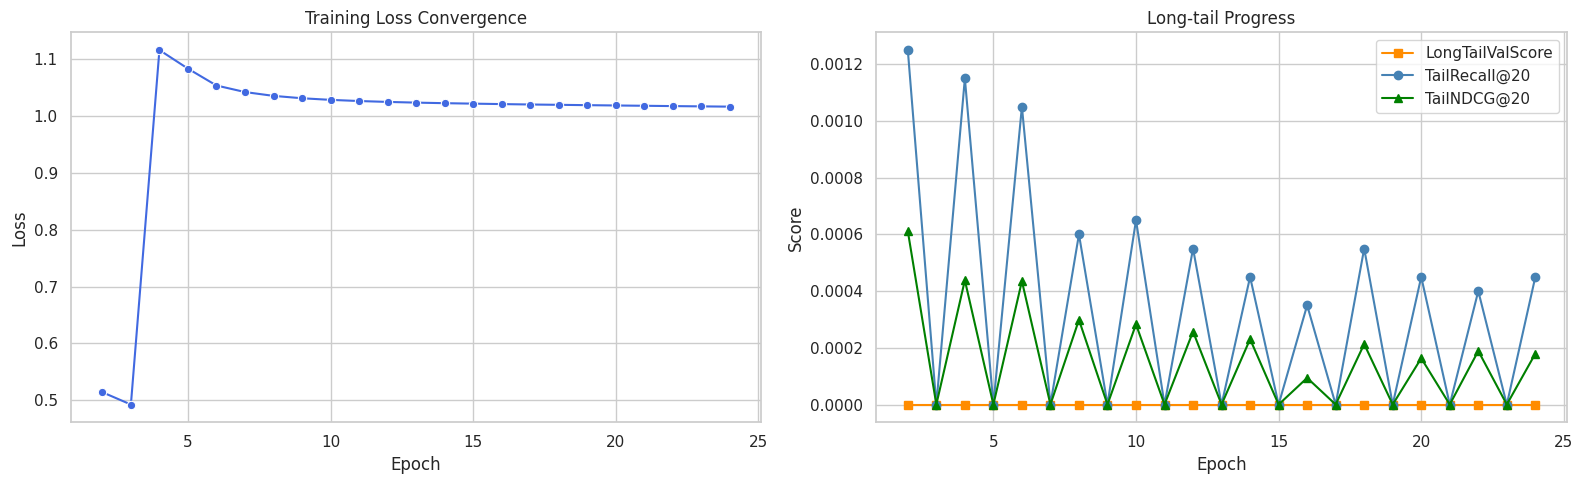

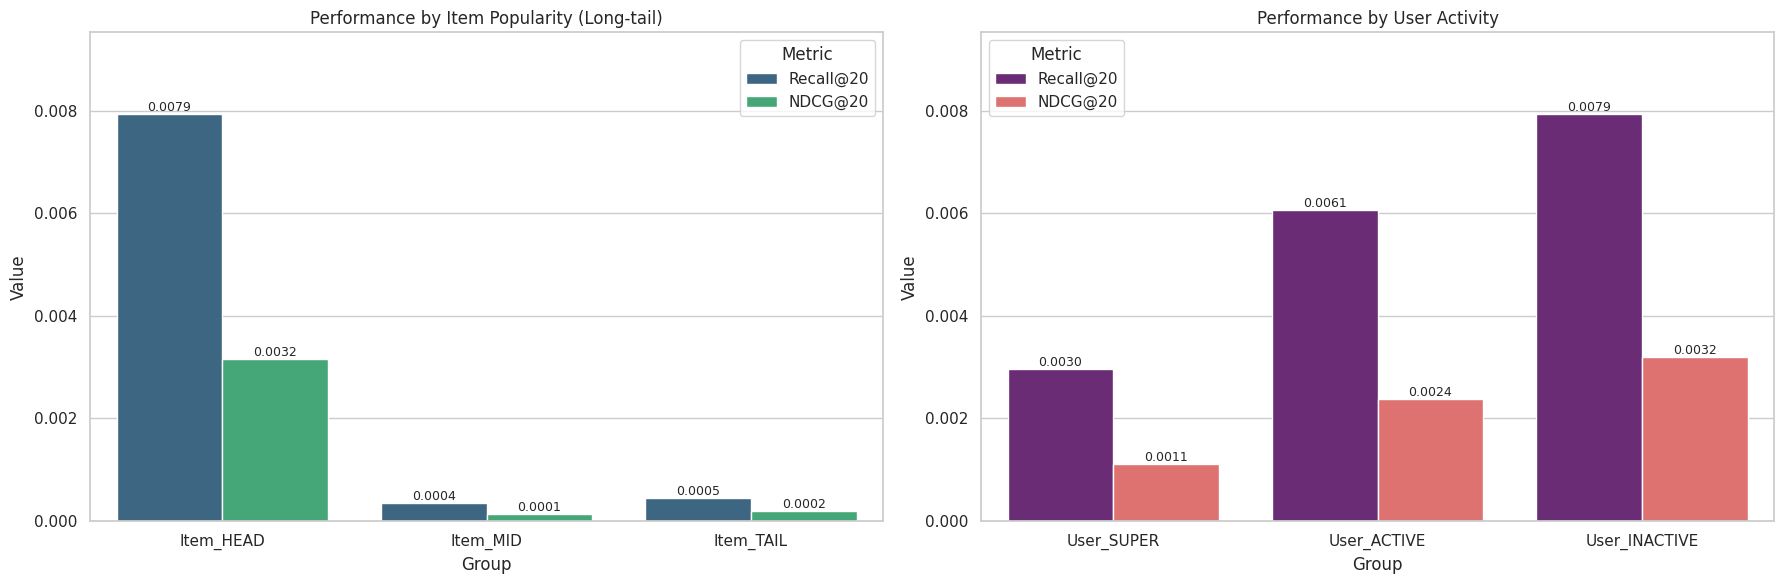

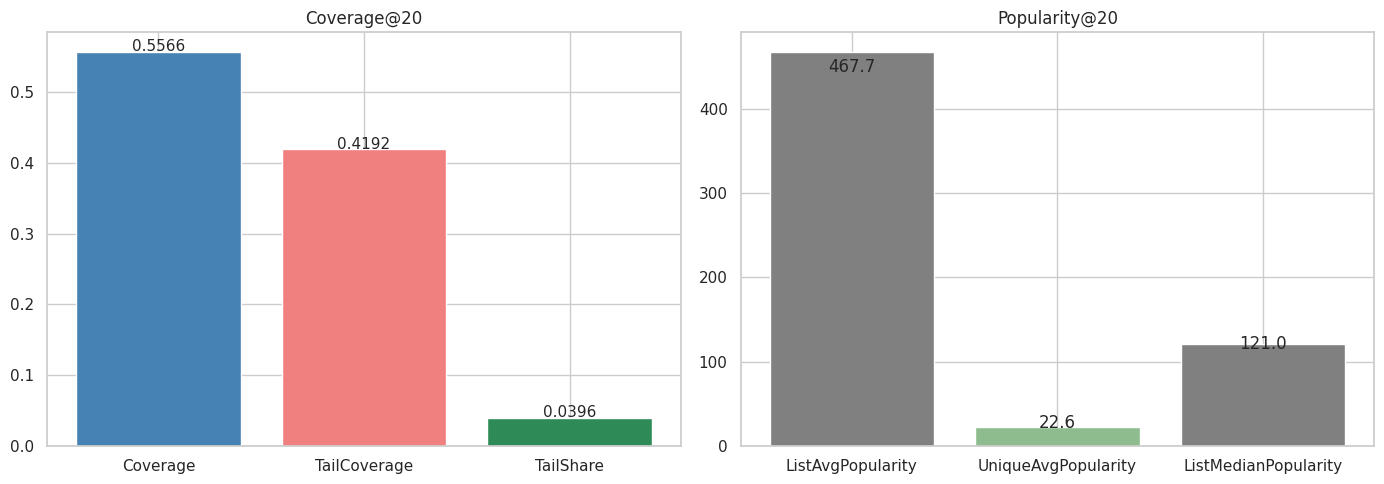

[INFO] Visualization complete. Full-ranking metrics only.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 18 (ĐÃ SỬA): VISUALIZATION – ĐẦY ĐỦ LONG-TAIL PHÂN TÍCH
# ══════════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [15, 5]
plt.rcParams['font.size'] = 12

# ── 1. Training History ──────────────────────────────────────────────────────────────
if "history" in globals() and history:
    epochs = [h['epoch'] for h in history]
    loss    = [h.get('loss', 0) for h in history]
    tail_score_hist = [h.get('LongTailValScore', h.get('TailScore', 0)) for h in history]
    tail_recall_hist = [h.get('TailRecall@K', 0) for h in history]
    tail_ndcg_hist = [h.get('TailNDCG@K', 0) for h in history]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    sns.lineplot(x=epochs, y=loss, ax=ax1, marker='o', color='royalblue')
    ax1.set_title("Training Loss Convergence")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")

    ax2.plot(epochs, tail_score_hist, 's-', color='darkorange', label='LongTailValScore')
    ax2.plot(epochs, tail_recall_hist, 'o-', color='steelblue', label='TailRecall@20')
    ax2.plot(epochs, tail_ndcg_hist, '^-', color='green', label='TailNDCG@20')
    ax2.set_title("Long‑tail Progress")
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Score")
    ax2.legend()
    plt.tight_layout()
    plt.show()
else:
    print("[WARN] Chưa có history.")

# ── 2. Full-Ranking Stratified Bar Charts ────────────────────────────────────
if "results_full" in globals():
    plot_data = []
    item_groups = ["Item_HEAD", "Item_MID", "Item_TAIL"]
    if "Item_COLD" in results_full and not CFG.get("IGNORE_COLD_ITEMS", True):
        item_groups.append("Item_COLD")
    user_groups = ["User_SUPER", "User_ACTIVE", "User_INACTIVE"]
    K = 20  # dùng K=20 cho biểu đồ

    for g in item_groups + user_groups:
        if g in results_full:
            n = results_full[g][K]["n"]
            rec = results_full[g][K]["hits"] / max(n, 1)
            ndcg = results_full[g][K]["ndcg"] / max(n, 1)
            plot_data.append({"Group": g, "Metric": "Recall@20", "Value": rec})
            plot_data.append({"Group": g, "Metric": "NDCG@20", "Value": ndcg})

    if plot_data:
        df_plot = pd.DataFrame(plot_data)
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
        sns.barplot(data=df_plot[df_plot['Group'].isin(item_groups)],
                    x='Group', y='Value', hue='Metric', ax=ax1, palette="viridis")
        ax1.set_title("Performance by Item Popularity (Long-tail)")
        ax1.set_ylim(0, max(df_plot['Value'])*1.2)
        for p in ax1.patches:
            if p.get_height() > 0:
                ax1.annotate(f'{p.get_height():.4f}', (p.get_x()+p.get_width()/2., p.get_height()),
                             ha='center', va='bottom', fontsize=9)

        sns.barplot(data=df_plot[df_plot['Group'].isin(user_groups)],
                    x='Group', y='Value', hue='Metric', ax=ax2, palette="magma")
        ax2.set_title("Performance by User Activity")
        ax2.set_ylim(0, max(df_plot['Value'])*1.2)
        for p in ax2.patches:
            if p.get_height() > 0:
                ax2.annotate(f'{p.get_height():.4f}', (p.get_x()+p.get_width()/2., p.get_height()),
                             ha='center', va='bottom', fontsize=9)
        plt.tight_layout()
        plt.show()

    # ── 3. Coverage & AvgPopularity biểu đồ riâng ─────────────────────────────
    fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(14, 5))
    covs = [results_full['Coverage@K'][K], results_full['TailCoverage@K'][K], results_full.get('TailShare@K', {}).get(K, 0.0)]
    ax3.bar(['Coverage', 'TailCoverage', 'TailShare'], covs, color=['steelblue', 'lightcoral', 'seagreen'])
    ax3.set_title(f'Coverage@{K}')
    for i, v in enumerate(covs):
        ax3.text(i, v+0.001, f'{v:.4f}', ha='center', fontsize=11)
    pop_labels = ['ListAvgPopularity']
    pop_values = [results_full.get('ListAvgPopularity@K', results_full['AvgPopularity@K'])[K]]
    if 'UniqueAvgPopularity@K' in results_full:
        pop_labels.append('UniqueAvgPopularity')
        pop_values.append(results_full['UniqueAvgPopularity@K'][K])
    if 'ListMedianPopularity@K' in results_full:
        pop_labels.append('ListMedianPopularity')
        pop_values.append(results_full['ListMedianPopularity@K'][K])
    ax4.bar(pop_labels, pop_values, color=['gray', 'darkseagreen'][:len(pop_labels)])
    ax4.set_title(f'Popularity@{K}')
    for idx, val in enumerate(pop_values):
        ax4.text(idx, val*0.95 if val > 0 else 0.01, f'{val:.1f}', ha='center')
    plt.tight_layout()
    plt.show()

else:
    print("[WARN] Chưa có results_full. Chạy Cell 15 trước.")


print("[INFO] Visualization complete. Full-ranking metrics only.")


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 19: TỰ NGẮT KẾT NỐI (tiết kiệm Compute Units)
# ═══════════════════════════════════════════════════════════════════════════════
import time

print("Toàn bộ pipeline đã hoàn tất và lưu lên Drive.")
print("Hệ thống sẽ ngắt kết nối sau 10 giây...")
time.sleep(10)

try:
    from google.colab import runtime
    runtime.unassign()
except:
    print("[INFO] Không ở môi trường Colab — bỏ qua ngắt kết nối.")

Toàn bộ pipeline đã hoàn tất và lưu lên Drive.
Hệ thống sẽ ngắt kết nối sau 10 giây...
